# Libraries

In [2]:
import evaluation_functions
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# Load files 

In [3]:
sd = pd.read_csv("merged_stable_diffusion.csv")
z_image = pd.read_csv("merged_z_image_turbo.csv")
flux = pd.read_csv("merged_flux.csv")
gemini = pd.read_csv("merged_gemini_flash.csv")
sc = pd.read_csv("merged_stable_cascade.csv")
dalle = pd.read_csv("merged_dalle.csv")

annotations = pd.concat([sd,z_image,flux, gemini, dalle, sc])


# Reorganize columns
annotations = annotations.loc[:, ["Image","Counting","WER","Spatial","Size","Emotion","Colors","Text","Cohesiveness","Code","Level","Robust"]]
annotations.head(3)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
0,stable_diffusion_0_easy_001_0.png,0.500,2.0,1.0,0.525,1.0,0.000,NaN,True,0,easy,False
1,stable_diffusion_0_easy_001_0_robust.png,0.585,2.0,1.0,0.500,0.5,0.415,NaN,True,0,easy,True
2,stable_diffusion_0_easy_001_1.png,0.500,2.0,0.0,0.000,0.0,0.000,NaN,False,0,easy,False


In [4]:
A = dict(annotations.count())
A

{'Image': np.int64(1627),
 'Counting': np.int64(698),
 'WER': np.int64(934),
 'Spatial': np.int64(1164),
 'Size': np.int64(1008),
 'Emotion': np.int64(967),
 'Colors': np.int64(1202),
 'Text': np.int64(450),
 'Cohesiveness': np.int64(1190),
 'Code': np.int64(1627),
 'Level': np.int64(1627),
 'Robust': np.int64(1627)}

In [5]:
A.pop("Image")
A.pop("Robust")
A.pop("Level")
A.pop("Code")

np.int64(1627)

In [6]:
sum(A.values())

np.int64(7613)

# Results by level

## Easy

In [7]:
annotations_easy = annotations[annotations["Level"]=="easy"]
annotations_easy.head(3)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
0,stable_diffusion_0_easy_001_0.png,0.500,2.0,1.0,0.525,1.0,0.000,NaN,True,0,easy,False
1,stable_diffusion_0_easy_001_0_robust.png,0.585,2.0,1.0,0.500,0.5,0.415,NaN,True,0,easy,True
2,stable_diffusion_0_easy_001_1.png,0.500,2.0,0.0,0.000,0.0,0.000,NaN,False,0,easy,False


### Numerical columns (easy)

In [8]:
annotations_easy.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,154.000000,195.000000,237.000000,211.000000,203.000000,252.000000,341.000000
mean,0.595130,1.245726,0.670886,0.723744,0.644245,0.765725,46.604106
std,0.334703,1.058117,0.366425,0.404914,0.427677,0.340485,38.658062
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.330000,0.208333,0.500000,0.500000,0.000000,0.500000,16.000000
50%,0.612500,1.000000,0.750000,1.000000,1.000000,1.000000,32.000000
75%,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,98.000000
max,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,112.000000


### Cohesiveness (easy)

In [9]:
annotations_easy["Cohesiveness"].describe()

count      241
unique       3
top       True
freq       120
Name: Cohesiveness, dtype: object

In [10]:
annotations_easy["Cohesiveness"].value_counts(normalize=True)

Cohesiveness
True     0.497925
True     0.265560
False    0.236515
Name: proportion, dtype: float64

In [11]:
len(annotations_easy[pd.notna(annotations_easy["Cohesiveness"])])

241

## Easy + robust

In [12]:
annotations_easy_robust = annotations_easy[annotations_easy["Robust"]==True]
annotations_easy_robust.head(3)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
1,stable_diffusion_0_easy_001_0_robust.png,0.585,2.0,1.00,0.5,0.5,0.415,NaN,True,0,easy,True
3,stable_diffusion_0_easy_001_1_robust.png,0.250,2.0,0.00,1.0,0.0,1.000,NaN,True,0,easy,True
21,stable_diffusion_100_easy_001_0_robust.png,0.500,1.0,0.75,0.0,1.0,NaN,NaN,True,100,easy,True


#### Numerical values (easy + robust)

In [13]:
annotations_easy_robust.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,79.000000,100.000000,120.000000,106.000000,104.000000,129.000000,176.000000
mean,0.573038,1.279167,0.671986,0.727547,0.641603,0.729129,46.636364
std,0.343103,1.039442,0.379645,0.415593,0.410503,0.370265,38.708930
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.330000,0.500000,0.500000,0.500000,0.310000,0.500000,16.000000
50%,0.585000,1.000000,0.791667,1.000000,0.915000,1.000000,32.000000
75%,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,100.000000
max,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,112.000000


### Cohesiveness (easy + robust)

In [14]:
annotations_easy_robust["Cohesiveness"].describe()

count      123
unique       3
top       True
freq        63
Name: Cohesiveness, dtype: object

## Easy + not robust

In [15]:
annotations_easy_not_robust = annotations_easy[annotations_easy["Robust"]==False]
annotations_easy_not_robust.head(3)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
0,stable_diffusion_0_easy_001_0.png,0.5,2.0,1.0,0.525,1.0,0.0,NaN,True,0,easy,False
2,stable_diffusion_0_easy_001_1.png,0.5,2.0,0.0,0.000,0.0,0.0,NaN,False,0,easy,False
20,stable_diffusion_100_easy_001_0.png,0.5,3.0,0.5,1.000,1.0,1.0,NaN,True,100,easy,False


### Numerical values (easy + not robust)

In [16]:
annotations_easy_not_robust.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,75.000000,95.000000,117.000000,105.000000,99.000000,123.000000,165.000000
mean,0.618400,1.210526,0.669758,0.719905,0.647020,0.804106,46.569697
std,0.326295,1.081821,0.353984,0.395799,0.447089,0.302938,38.721524
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.400000,0.000000,0.500000,0.500000,0.000000,0.602500,16.000000
50%,0.670000,1.000000,0.750000,1.000000,1.000000,1.000000,32.000000
75%,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,96.000000
max,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,112.000000


### Cohesiveness (easy + not robust)

In [17]:
annotations_easy_not_robust["Cohesiveness"].describe()

count      118
unique       3
top       True
freq        57
Name: Cohesiveness, dtype: object

## Medium

In [18]:
annotations_medium = annotations[annotations["Level"]=="medium"]
annotations_medium.head(3)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
14,stable_diffusion_0_medium_001_0.png,0.200,6.0,0.000,0.000,0.0,0.333333,NaN,False,0,medium,False
15,stable_diffusion_0_medium_001_0_robust.png,0.300,6.0,0.500,0.250,0.0,0.000000,STOP,True,0,medium,True
16,stable_diffusion_0_medium_001_1.png,0.125,6.0,0.125,0.125,0.0,0.580000,NaN,NaN,0,medium,False


### Numerical columns (medium)

In [19]:
annotations_medium.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,203.000000,285.000000,345.000000,298.000000,283.000000,364.000000,486.000000
mean,0.400130,2.743784,0.498102,0.525850,0.438045,0.642408,44.213992
std,0.320815,2.380488,0.378420,0.396079,0.416778,0.404423,38.514952
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125000,0.250000,0.000000,0.000000,0.000000,0.280000,14.000000
50%,0.330000,3.000000,0.500000,0.500000,0.500000,0.787778,30.000000
75%,0.600000,5.000000,0.830000,1.000000,1.000000,1.000000,94.500000
max,1.000000,6.000000,1.000000,1.000000,1.000000,1.000000,112.000000


### Cohesiveness (medium)

In [20]:
annotations_medium["Cohesiveness"].value_counts(normalize=True)

Cohesiveness
False    0.369628
True     0.369628
True     0.234957
0.5      0.014327
False    0.011461
Name: proportion, dtype: float64

In [21]:
annotations_medium["Cohesiveness"].describe()

count       349
unique        5
top       False
freq        129
Name: Cohesiveness, dtype: object

## Medium + robust

In [22]:
annotations_medium_robust = annotations_medium[annotations_medium["Robust"]==True]
annotations_medium_robust.head(2)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
15,stable_diffusion_0_medium_001_0_robust.png,0.3,6.0,0.500,0.250,0.0,0.0,STOP,True,0,medium,True
17,stable_diffusion_0_medium_001_1_robust.png,0.3,4.0,0.165,0.165,0.0,0.0,STTO; STOP STAIRE;,True,0,medium,True


### Numerical columns (medium + robust)

In [23]:
annotations_medium_robust.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,109.000000,143.000000,173.000000,149.000000,148.000000,190.000000,250.000000
mean,0.327982,2.554021,0.482704,0.508680,0.410304,0.631800,43.608000
std,0.292545,2.282856,0.385541,0.400107,0.414499,0.407097,37.802997
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.200000,0.000000,0.000000,0.000000,0.178750,14.000000
50%,0.325000,2.500000,0.500000,0.500000,0.437500,0.750000,30.000000
75%,0.500000,5.000000,0.812500,1.000000,1.000000,1.000000,64.000000
max,1.000000,6.000000,1.000000,1.000000,1.000000,1.000000,112.000000


### Cohesiveness (medium + robust)

In [24]:
annotations_medium_robust["Cohesiveness"].describe()

count       180
unique        5
top       False
freq         69
Name: Cohesiveness, dtype: object

## Medium + not robust

In [25]:
annotations_medium_not_robust = annotations_medium[annotations_medium["Robust"]==False]
annotations_medium_not_robust.head(3)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
14,stable_diffusion_0_medium_001_0.png,0.200,6.0,0.000,0.000,0.0,0.333333,NaN,False,0,medium,False
16,stable_diffusion_0_medium_001_1.png,0.125,6.0,0.125,0.125,0.0,0.580000,NaN,NaN,0,medium,False
18,stable_diffusion_0_medium_001_2.png,0.400,6.0,0.500,0.250,0.0,0.000000,NaN,False,0,medium,False


### Numerical values (medium + not robust)

In [26]:
annotations_medium_not_robust.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,94.000000,142.000000,172.000000,149.000000,135.000000,174.000000,236.000000
mean,0.483791,2.934884,0.513590,0.543020,0.468457,0.653992,44.855932
std,0.333152,2.468226,0.371600,0.392605,0.418684,0.402335,39.325326
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250000,0.308333,0.176667,0.000000,0.000000,0.300000,14.000000
50%,0.500000,4.000000,0.500000,0.600000,0.500000,0.935000,29.000000
75%,0.750000,5.000000,0.881250,1.000000,1.000000,1.000000,98.500000
max,1.000000,6.000000,1.000000,1.000000,1.000000,1.000000,112.000000


### Cohesiveness (medium + not robust)

In [27]:
annotations_medium_not_robust["Cohesiveness"].describe()

count      169
unique       5
top       True
freq        61
Name: Cohesiveness, dtype: object

## Hard

In [28]:
annotations_hard = annotations[annotations["Level"]=="hard"]
annotations_hard.head(3)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
4,stable_diffusion_0_hard_001_0.png,0.0,6.0,0.11,0.0,0.165,0.25,NaN,False,0,hard,False
5,stable_diffusion_0_hard_001_0_robust.png,0.0,8.0,0.50,0.0,0.000,0.00,NaN,False,0,hard,True
6,stable_diffusion_0_hard_001_1.png,0.0,6.0,0.50,0.0,0.000,0.00,NaN,False,0,hard,False


### Numerical values (hard)

In [29]:
annotations_hard.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,341.000000,454.000000,582.000000,499.000000,481.000000,586.000000,800.000000
mean,0.263768,3.980743,0.475135,0.558991,0.400066,0.624918,45.835000
std,0.252185,3.302105,0.362879,0.406148,0.398821,0.390960,39.188039
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.333333,0.017500,0.000000,0.000000,0.250000,16.000000
50%,0.200000,6.000000,0.500000,0.633333,0.316667,0.750000,31.000000
75%,0.415000,7.000000,0.800000,1.000000,0.750000,1.000000,100.000000
max,1.000000,9.000000,1.000000,1.000000,1.165000,1.000000,112.000000


### Cohesiveness (hard)

In [30]:
annotations_hard["Cohesiveness"].value_counts(normalize=True)

Cohesiveness
False    0.458333
True     0.270000
True     0.253333
False    0.010000
0.5      0.008333
Name: proportion, dtype: float64

In [31]:
annotations_hard["Cohesiveness"].describe()

count       600
unique        5
top       False
freq        275
Name: Cohesiveness, dtype: object

## Hard + robust

In [32]:
annotations_hard_robust = annotations_hard[annotations_hard["Robust"]==True]
annotations_hard_robust.head(3)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
5,stable_diffusion_0_hard_001_0_robust.png,0.00,8.0,0.5,0.0,0.0,0.0,NaN,False,0,hard,True
7,stable_diffusion_0_hard_001_1_robust.png,0.14,8.0,0.0,0.0,0.0,0.0,NaN,False,0,hard,True
9,stable_diffusion_0_hard_001_2_robust.png,0.00,8.0,0.5,0.0,0.0,0.0,NaN,False,0,hard,True


### Numercial values (hard + robust)

In [33]:
annotations_hard_robust.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,176.000000,229.000000,290.000000,249.000000,260.000000,308.000000,414.000000
mean,0.263892,4.406004,0.459149,0.525459,0.421609,0.607026,45.275362
std,0.260349,3.289681,0.373415,0.423162,0.407572,0.392881,38.814097
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.487500,0.000000,0.000000,0.000000,0.250000,14.500000
50%,0.225000,6.000000,0.500000,0.527778,0.330000,0.750000,32.000000
75%,0.435000,7.000000,0.800000,1.000000,1.000000,1.000000,96.000000
max,1.000000,8.000000,1.000000,1.000000,1.000000,1.000000,112.000000


### Cohesiveness (hard + robust)

In [34]:
annotations_hard_robust["Cohesiveness"].describe()

count       298
unique        5
top       False
freq        140
Name: Cohesiveness, dtype: object

## Hard + not robust

In [35]:
annotations_hard_not_robust = annotations_hard[annotations_hard["Robust"]==False]
annotations_hard_not_robust.head(3)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
4,stable_diffusion_0_hard_001_0.png,0.0,6.0,0.11,0.00,0.165000,0.25,NaN,False,0,hard,False
6,stable_diffusion_0_hard_001_1.png,0.0,6.0,0.50,0.00,0.000000,0.00,NaN,False,0,hard,False
8,stable_diffusion_0_hard_001_2.png,0.1,6.0,0.54,0.22,0.166667,0.35,NaN,False,0,hard,False


### Numercial values (hard + not robust)

In [36]:
annotations_hard_not_robust.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,165.000000,225.000000,292.000000,250.000000,221.000000,278.000000,386.000000
mean,0.263636,3.547922,0.491013,0.592389,0.374721,0.644741,46.435233
std,0.243967,3.265407,0.352026,0.386421,0.387658,0.388564,39.626794
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.166667,0.136250,0.250000,0.000000,0.297500,16.000000
50%,0.200000,3.000000,0.500000,0.687500,0.300000,0.750000,30.000000
75%,0.400000,7.000000,0.783333,1.000000,0.665000,1.000000,100.000000
max,1.000000,9.000000,1.000000,1.000000,1.165000,1.000000,112.000000


### Cohesiveness (hard + not robust)

In [37]:
annotations_hard_not_robust["Cohesiveness"].describe()

count       302
unique        5
top       False
freq        135
Name: Cohesiveness, dtype: object

# Focus on "All skills (0)"

In [38]:
annotations_0 = annotations[annotations["Code"]==0]
annotations_0.head(2)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
0,stable_diffusion_0_easy_001_0.png,0.500,2.0,1.0,0.525,1.0,0.000,NaN,True,0,easy,False
1,stable_diffusion_0_easy_001_0_robust.png,0.585,2.0,1.0,0.500,0.5,0.415,NaN,True,0,easy,True


### Numerical values

In [39]:
annotations_0.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,119.000000,119.000000,107.000000,102.000000,119.000000,118.000000,119.0
mean,0.421987,2.908985,0.573172,0.607285,0.477568,0.673195,0.0
std,0.355154,3.054794,0.367429,0.397711,0.457709,0.399676,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.112500,0.166667,0.267857,0.250000,0.000000,0.333333,0.0
50%,0.330000,1.000000,0.600000,0.690476,0.498333,0.906250,0.0
75%,0.710000,6.000000,1.000000,1.000000,1.000000,1.000000,0.0
max,1.000000,8.000000,1.000000,1.000000,1.000000,1.000000,0.0


### Cohesiveness

In [40]:
annotations_0["Cohesiveness"].describe()

count       110
unique        5
top       False
freq         49
Name: Cohesiveness, dtype: object

## All skills + robust

In [41]:
annotations_0_robust = annotations_0[annotations_0["Robust"]==True]
annotations_0_robust.head(2)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
1,stable_diffusion_0_easy_001_0_robust.png,0.585,2.0,1.0,0.5,0.5,0.415,NaN,True,0,easy,True
3,stable_diffusion_0_easy_001_1_robust.png,0.250,2.0,0.0,1.0,0.0,1.000,NaN,True,0,easy,True


### Numerical values

In [42]:
annotations_0_robust.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,59.000000,59.000000,55.000000,51.000000,59.000000,59.000000,59.0
mean,0.384746,3.453178,0.563919,0.521587,0.464322,0.687153,0.0
std,0.336349,3.443929,0.366178,0.399500,0.462262,0.391900,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.035000,0.104167,0.250000,0.082500,0.000000,0.415833,0.0
50%,0.330000,2.000000,0.600000,0.500000,0.498333,0.833333,0.0
75%,0.600000,8.000000,0.950000,1.000000,1.000000,1.000000,0.0
max,1.000000,8.000000,1.000000,1.000000,1.000000,1.000000,0.0


## All skills + not robust

In [43]:
annotations_0_not_robust = annotations_0[annotations_0["Robust"]==False]
annotations_0_not_robust.head(2)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
0,stable_diffusion_0_easy_001_0.png,0.5,2.0,1.0,0.525,1.0,0.0,NaN,True,0,easy,False
2,stable_diffusion_0_easy_001_1.png,0.5,2.0,0.0,0.000,0.0,0.0,NaN,False,0,easy,False


### Numerical values

In [44]:
annotations_0_not_robust.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,60.000000,60.000000,52.000000,51.000000,60.000000,59.000000,60.0
mean,0.458607,2.373862,0.582958,0.692983,0.490593,0.659237,0.0
std,0.371893,2.533093,0.372066,0.380696,0.456709,0.410188,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.158750,0.166667,0.364583,0.500000,0.000000,0.304583,0.0
50%,0.400000,1.000000,0.662500,1.000000,0.471111,0.937500,0.0
75%,0.835350,6.000000,1.000000,1.000000,1.000000,1.000000,0.0
max,1.000000,6.000000,1.000000,1.000000,1.000000,1.000000,0.0


## All skills (easy)

In [45]:
annotations_0_easy = annotations_0[annotations_0["Level"]=="easy"]
annotations_0_easy.head(2)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
0,stable_diffusion_0_easy_001_0.png,0.500,2.0,1.0,0.525,1.0,0.000,NaN,True,0,easy,False
1,stable_diffusion_0_easy_001_0_robust.png,0.585,2.0,1.0,0.500,0.5,0.415,NaN,True,0,easy,True


### Numerical values (easy)

In [46]:
annotations_0_easy.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,24.000000,24.000000,22.000000,22.000000,24.000000,24.000000,24.0
mean,0.715417,1.156250,0.709318,0.702727,0.729167,0.760347,0.0
std,0.351982,0.740199,0.418649,0.391498,0.409909,0.398817,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.500000,0.687500,0.456250,0.500000,0.500000,0.478750,0.0
50%,0.855000,1.000000,0.950000,1.000000,1.000000,1.000000,0.0
75%,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.0
max,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.0


### Cohesiveness (easy)

In [47]:
annotations_0_easy["Cohesiveness"].describe()

count       24
unique       3
top       True
freq        15
Name: Cohesiveness, dtype: object

In [48]:
annotations_0_easy["Cohesiveness"].value_counts()

Cohesiveness
True     15
False     5
True      4
Name: count, dtype: int64

## All skills (easy + robust)

In [49]:
annotations_0_easy_robust = annotations_0_easy[annotations_0_easy["Robust"]==True]
annotations_0_easy_robust.head(2)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
1,stable_diffusion_0_easy_001_0_robust.png,0.585,2.0,1.0,0.5,0.5,0.415,NaN,True,0,easy,True
3,stable_diffusion_0_easy_001_1_robust.png,0.250,2.0,0.0,1.0,0.0,1.000,NaN,True,0,easy,True


### Numerical values (easy + robust)

In [50]:
annotations_0_easy_robust.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,12.000000,12.000000,11.000000,11.000000,12.000000,12.000000,12.0
mean,0.684167,1.354167,0.793636,0.772727,0.541667,0.729028,0.0
std,0.390610,0.726592,0.396290,0.410100,0.437365,0.416212,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.501250,0.937500,0.865000,0.750000,0.000000,0.394583,0.0
50%,0.812500,1.500000,1.000000,1.000000,0.625000,1.000000,0.0
75%,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.0
max,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.0


### Cohesiveness (easy + robust)

In [51]:
annotations_0_easy_robust["Cohesiveness"].describe()

count       12
unique       3
top       True
freq         8
Name: Cohesiveness, dtype: object

## All skills (easy + not robust)

In [52]:
annotations_0_easy_not_robust = annotations_0_easy[annotations_0_easy["Robust"]==False]
annotations_0_easy_not_robust.head(2)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
0,stable_diffusion_0_easy_001_0.png,0.5,2.0,1.0,0.525,1.0,0.0,NaN,True,0,easy,False
2,stable_diffusion_0_easy_001_1.png,0.5,2.0,0.0,0.000,0.0,0.0,NaN,False,0,easy,False


### Numerical values (easy + not robust)

In [53]:
annotations_0_easy_not_robust.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,12.000000,12.000000,11.000000,11.000000,12.000000,12.000000,12.0
mean,0.746667,0.958333,0.625000,0.632727,0.916667,0.791667,0.0
std,0.323014,0.729518,0.442012,0.378030,0.288675,0.396481,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.500000,0.437500,0.187500,0.500000,1.000000,0.875000,0.0
50%,0.917500,1.000000,0.900000,0.600000,1.000000,1.000000,0.0
75%,1.000000,1.250000,1.000000,1.000000,1.000000,1.000000,0.0
max,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.0


### Cohesiveness (easy + not robust)

In [54]:
annotations_0_easy_not_robust["Cohesiveness"].describe()

count       12
unique       3
top       True
freq         7
Name: Cohesiveness, dtype: object

## All skills (medium)

In [55]:
annotations_0_medium = annotations_0[annotations_0["Level"]=="medium"]
annotations_0_medium.head(3)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
14,stable_diffusion_0_medium_001_0.png,0.200,6.0,0.000,0.000,0.0,0.333333,NaN,False,0,medium,False
15,stable_diffusion_0_medium_001_0_robust.png,0.300,6.0,0.500,0.250,0.0,0.000000,STOP,True,0,medium,True
16,stable_diffusion_0_medium_001_1.png,0.125,6.0,0.125,0.125,0.0,0.580000,NaN,NaN,0,medium,False


### Numerical values (medium)

In [56]:
annotations_0_medium.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,35.000000,35.000000,33.000000,29.000000,35.000000,35.000000,35.0
mean,0.582469,2.689388,0.525498,0.694540,0.471429,0.696790,0.0
std,0.338695,2.747384,0.354588,0.358943,0.468773,0.407614,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.330000,0.125000,0.250000,0.500000,0.000000,0.456667,0.0
50%,0.600000,0.666667,0.500000,0.830000,0.500000,1.000000,0.0
75%,0.950000,6.000000,0.800000,1.000000,1.000000,1.000000,0.0
max,1.000000,6.000000,1.000000,1.000000,1.000000,1.000000,0.0


### Cohesiveness (medium)

In [57]:
annotations_0_medium["Cohesiveness"].value_counts()

Cohesiveness
False    13
True     13
0.5       4
True      2
Name: count, dtype: int64

## All skills (medium + robust)

In [58]:
annotations_0_medium_robust = annotations_0_medium[annotations_0_medium["Robust"]==True]
annotations_0_medium_robust.head(3)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
15,stable_diffusion_0_medium_001_0_robust.png,0.3,6.0,0.500,0.250,0.0,0.000000,STOP,True,0,medium,True
17,stable_diffusion_0_medium_001_1_robust.png,0.3,4.0,0.165,0.165,0.0,0.000000,STTO; STOP STAIRE;,True,0,medium,True
19,stable_diffusion_0_medium_001_2_robust.png,0.0,6.0,0.000,0.000,0.0,0.144444,NaN,False,0,medium,True


### Numerical values (medium + robust)

In [61]:
annotations_0_medium_robust.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,17.000000,17.000000,17.000000,14.000000,17.000000,17.000000,17.0
mean,0.448824,2.374510,0.385378,0.652619,0.558824,0.641038,0.0
std,0.307426,2.653281,0.277962,0.364473,0.496310,0.430292,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.300000,0.083333,0.165000,0.353750,0.000000,0.144444,0.0
50%,0.400000,0.666667,0.500000,0.708333,1.000000,0.833333,0.0
75%,0.600000,6.000000,0.600000,1.000000,1.000000,1.000000,0.0
max,1.000000,6.000000,0.800000,1.000000,1.000000,1.000000,0.0


### Cohesiveness (medium + robust)

In [62]:
annotations_0_medium_robust["Cohesiveness"].describe()

count       16
unique       4
top       True
freq         8
Name: Cohesiveness, dtype: object

## All skills (medium + not robust)

In [63]:
annotations_0_medium_not_robust = annotations_0_medium[annotations_0_medium["Robust"]==False]
annotations_0_medium_not_robust.head(3)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
14,stable_diffusion_0_medium_001_0.png,0.200,6.0,0.000,0.000,0.0,0.333333,NaN,False,0,medium,False
16,stable_diffusion_0_medium_001_1.png,0.125,6.0,0.125,0.125,0.0,0.580000,NaN,NaN,0,medium,False
18,stable_diffusion_0_medium_001_2.png,0.400,6.0,0.500,0.250,0.0,0.000000,NaN,False,0,medium,False


### Numerical values (medium + not robust)

In [64]:
annotations_0_medium_not_robust.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,18.000000,18.000000,16.000000,15.000000,18.000000,18.000000,18.0
mean,0.708689,2.986772,0.674375,0.733667,0.388889,0.749444,0.0
std,0.325187,2.877092,0.374063,0.361843,0.439102,0.389865,0.0
min,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.347500,0.208333,0.478750,0.500000,0.000000,0.621667,0.0
50%,0.835700,2.083333,0.750000,1.000000,0.250000,1.000000,0.0
75%,1.000000,6.000000,1.000000,1.000000,0.875000,1.000000,0.0
max,1.000000,6.000000,1.000000,1.000000,1.000000,1.000000,0.0


### Cohesiveness (medium + not robust)

In [65]:
annotations_0_medium_not_robust["Cohesiveness"].describe()

count        16
unique        4
top       False
freq          8
Name: Cohesiveness, dtype: object

## All skills (hard)

In [66]:
annotations_0_hard = annotations_0[annotations_0["Level"]=="hard"]
annotations_0_hard.head(3)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
4,stable_diffusion_0_hard_001_0.png,0.0,6.0,0.11,0.0,0.165,0.25,NaN,False,0,hard,False
5,stable_diffusion_0_hard_001_0_robust.png,0.0,8.0,0.50,0.0,0.000,0.00,NaN,False,0,hard,True
6,stable_diffusion_0_hard_001_1.png,0.0,6.0,0.50,0.0,0.000,0.00,NaN,False,0,hard,False


### Numerical values (hard)

In [67]:
annotations_0_hard.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,60.000000,60.000000,52.000000,51.000000,60.000000,59.000000,60.0
mean,0.211000,3.738178,0.545826,0.516499,0.380509,0.623746,0.0
std,0.205653,3.481767,0.345410,0.407623,0.437615,0.394713,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,0.156250,0.321429,0.000000,0.000000,0.273333,0.0
50%,0.200000,2.650000,0.570000,0.500000,0.165833,0.791667,0.0
75%,0.330000,8.000000,0.814286,1.000000,1.000000,1.000000,0.0
max,0.800000,8.000000,1.000000,1.000000,1.000000,1.000000,0.0


### Cohesiveness (hard)

In [68]:
annotations_0_hard["Cohesiveness"].describe()

count        54
unique        5
top       False
freq         31
Name: Cohesiveness, dtype: object

In [69]:
annotations_0_hard["Cohesiveness"].value_counts()

Cohesiveness
False    31
True     13
0.5       4
True      4
False     2
Name: count, dtype: int64

## All skills (hard + robust)

In [70]:
annotations_0_hard_robust = annotations_0_hard[annotations_0_hard["Robust"]==True]
annotations_0_hard_robust.head(3)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
5,stable_diffusion_0_hard_001_0_robust.png,0.00,8.0,0.5,0.0,0.0,0.0,NaN,False,0,hard,True
7,stable_diffusion_0_hard_001_1_robust.png,0.14,8.0,0.0,0.0,0.0,0.0,NaN,False,0,hard,True
9,stable_diffusion_0_hard_001_2_robust.png,0.00,8.0,0.5,0.0,0.0,0.0,NaN,False,0,hard,True


### Numerical values (hard + robust)

In [71]:
annotations_0_hard_robust.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,30.000000,30.000000,27.000000,26.000000,30.000000,30.000000,30.0
mean,0.228667,4.904028,0.582746,0.344780,0.379833,0.696534,0.0
std,0.227019,3.867070,0.356375,0.336115,0.451461,0.370468,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,0.078125,0.335165,0.000000,0.000000,0.508333,0.0
50%,0.185000,8.000000,0.633333,0.312500,0.000000,0.816667,0.0
75%,0.330000,8.000000,0.950000,0.533730,0.958333,1.000000,0.0
max,0.800000,8.000000,1.000000,1.000000,1.000000,1.000000,0.0


### Cohesiveness (hard + robust)

In [72]:
annotations_0_hard_robust["Cohesiveness"].describe()

count        27
unique        5
top       False
freq         15
Name: Cohesiveness, dtype: object

## All skills (hard + not robust)

In [73]:
annotations_0_hard_not_robust = annotations_0_hard[annotations_0_hard["Robust"]==False]
annotations_0_hard_not_robust.head(3)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust
4,stable_diffusion_0_hard_001_0.png,0.0,6.0,0.11,0.00,0.165000,0.25,NaN,False,0,hard,False
6,stable_diffusion_0_hard_001_1.png,0.0,6.0,0.50,0.00,0.000000,0.00,NaN,False,0,hard,False
8,stable_diffusion_0_hard_001_2.png,0.1,6.0,0.54,0.22,0.166667,0.35,NaN,False,0,hard,False


### Numerical values (hard + not robust)

In [74]:
annotations_0_hard_not_robust.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code
count,30.000000,30.000000,25.000000,25.000000,30.000000,29.000000,30.0
mean,0.193333,2.572328,0.505952,0.695086,0.381185,0.548448,0.0
std,0.184013,2.626224,0.335787,0.404119,0.431044,0.411131,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,0.166667,0.333333,0.300000,0.000000,0.200000,0.0
50%,0.200000,1.000000,0.533333,1.000000,0.166667,0.550000,0.0
75%,0.330000,6.000000,0.750000,1.000000,0.958333,1.000000,0.0
max,0.585000,6.000000,1.000000,1.000000,1.000000,1.000000,0.0


### Cohesiveness (hard + not robust)

In [75]:
annotations_0_hard_not_robust["Cohesiveness"].describe()

count        27
unique        5
top       False
freq         16
Name: Cohesiveness, dtype: object

# Focus on "Best combination"

## Filtering by cohesiveness = True

In [76]:
#annotations_cohesive = annotations[annotations["Cohesiveness"]==True]
#annotations_cohesive.head(3)

## Best combination (overall)

In [77]:
evaluation_functions.compute_combinations(annotations,test="all")

Max counting: 1.0 -  Min WER: 0.0 - Max spatial: 1.0 -          
Max size: 1.0 - Max emotion: 1.165 - Max colors: 1.0 
Skill codes (all):
- Counting (all): [np.int64(106), np.int64(110), np.int64(112), np.int64(12), np.int64(24), np.int64(26), np.int64(28), np.int64(30), np.int64(50), np.int64(72), np.int64(0), np.int64(32), np.int64(34), np.int64(36), np.int64(38), np.int64(40), np.int64(44), np.int64(46), np.int64(48), np.int64(100), np.int64(102), np.int64(42)]        
- WER (all) : [np.int64(58), np.int64(0), np.int64(100), np.int64(104), np.int64(108), np.int64(10), np.int64(112), np.int64(14), np.int64(18), np.int64(22), np.int64(26), np.int64(2), np.int64(30), np.int64(32), np.int64(36), np.int64(40), np.int64(44), np.int64(6)]        
- Spatial (all) : [np.int64(0), np.int64(102), np.int64(104), np.int64(106), np.int64(10), np.int64(110), np.int64(112), np.int64(14), np.int64(18), np.int64(20), np.int64(22), np.int64(24), np.int64(26), np.int64(28), np.int64(42), np.int64(44), 

0

## Z-Image-turbo

In [78]:
%load_ext autoreload
%autoreload now
import evaluation_functions

## Best combinations (easy)

In [79]:
# Extract the cohesive "Easy" annotations
annotations_cohesive_easy = annotations[annotations["Level"]=="easy"]
evaluation_functions.compute_combinations(annotations_cohesive_easy,test="easy")

Max counting: 1.0 -  Min WER: 0.0 - Max spatial: 1.0 -          
Max size: 1.0 - Max emotion: 1.0 - Max colors: 1.0 
Skill codes (easy):
- Counting (easy): [np.int64(24), np.int64(26), np.int64(28), np.int64(50), np.int64(72), np.int64(0), np.int64(32), np.int64(34), np.int64(36), np.int64(38), np.int64(40), np.int64(44), np.int64(46), np.int64(48), np.int64(100), np.int64(42)]        
- WER (easy) : [np.int64(58), np.int64(0), np.int64(100), np.int64(108), np.int64(10), np.int64(112), np.int64(14), np.int64(18), np.int64(26), np.int64(2), np.int64(36), np.int64(40), np.int64(104), np.int64(22), np.int64(30), np.int64(32), np.int64(6)]        
- Spatial (easy) : [np.int64(0), np.int64(102), np.int64(110), np.int64(112), np.int64(22), np.int64(26), np.int64(28), np.int64(42), np.int64(44), np.int64(46), np.int64(48), np.int64(100), np.int64(104), np.int64(106), np.int64(108), np.int64(14), np.int64(16), np.int64(18), np.int64(20), np.int64(24)]        
- Size (easy) : [np.int64(0), np.i

0

## Best combinations (medium)

In [80]:
# Extract the cohesive "medium" annotations
annotations_cohesive_medium = annotations[annotations["Level"]=="medium"]
evaluation_functions.compute_combinations(annotations_cohesive_medium,test="medium")

Max counting: 1.0 -  Min WER: 0.0 - Max spatial: 1.0 -          
Max size: 1.0 - Max emotion: 1.0 - Max colors: 1.0 
Skill codes (medium):
- Counting (medium): [np.int64(106), np.int64(112), np.int64(12), np.int64(24), np.int64(0), np.int64(32), np.int64(36), np.int64(40), np.int64(46), np.int64(48), np.int64(34)]        
- WER (medium) : [np.int64(0), np.int64(100), np.int64(104), np.int64(10), np.int64(112), np.int64(14), np.int64(18), np.int64(22), np.int64(26), np.int64(2), np.int64(30), np.int64(32), np.int64(36), np.int64(40), np.int64(44), np.int64(108), np.int64(6)]        
- Spatial (medium) : [np.int64(104), np.int64(106), np.int64(14), np.int64(18), np.int64(20), np.int64(24), np.int64(42), np.int64(48), np.int64(54), np.int64(0), np.int64(102), np.int64(110), np.int64(112), np.int64(16), np.int64(22), np.int64(26), np.int64(44), np.int64(108), np.int64(28)]        
- Size (medium) : [np.int64(104), np.int64(108), np.int64(10), np.int64(110), np.int64(112), np.int64(12), np.

0

## Best combinations (hard)

In [81]:
# Extract the cohesive "medium" annotations
annotations_cohesive_hard = annotations[annotations["Level"]=="hard"]
evaluation_functions.compute_combinations(annotations_cohesive_hard,test="hard")

Max counting: 1.0 -  Min WER: 0.0 - Max spatial: 1.0 -          
Max size: 1.0 - Max emotion: 1.165 - Max colors: 1.0 
Skill codes (hard):
- Counting (hard): [np.int64(110), np.int64(112), np.int64(30), np.int64(100), np.int64(102)]        
- WER (hard) : [np.int64(0), np.int64(100), np.int64(108), np.int64(10), np.int64(112), np.int64(14), np.int64(18), np.int64(22), np.int64(26), np.int64(2), np.int64(30), np.int64(32), np.int64(36), np.int64(40), np.int64(44), np.int64(104), np.int64(6)]        
- Spatial (hard) : [np.int64(0), np.int64(104), np.int64(106), np.int64(10), np.int64(112), np.int64(14), np.int64(18), np.int64(20), np.int64(22), np.int64(24), np.int64(26), np.int64(28), np.int64(88), np.int64(100), np.int64(102), np.int64(108), np.int64(110), np.int64(16), np.int64(44), np.int64(46), np.int64(48)]        
- Size (hard) : [np.int64(104), np.int64(106), np.int64(108), np.int64(10), np.int64(110), np.int64(112), np.int64(12), np.int64(14), np.int64(18), np.int64(24), np.int

0

In [82]:
len(annotations)

1627

# Evaluate agreements

In [83]:
agreements_sd = pd.read_csv("agreements_stable_diffusion.csv")
agreements_dalle = pd.read_csv("agreements_dalle.csv")
agreements_flux = pd.read_csv("agreements_flux.csv")
agreements_zimage = pd.read_csv("agreements_z_image_turbo.csv")

total = pd.concat([agreements_sd,agreements_dalle,agreements_flux,agreements_zimage])
agreements = pd.concat([agreements_sd,agreements_dalle,agreements_flux,agreements_zimage])
agreements = agreements.loc[:, ["Counting","Text","Spatial","Size","Emotion","Colors","Level","Robust","Code"]]

agreements.head()

,Counting,Text,Spatial,Size,Emotion,Colors,Level,Robust,Code
0,0.00,0.0,0.00,0.03,0.00,0.00,easy,False,0
1,0.09,0.0,0.00,0.50,0.50,0.08,easy,True,0
2,0.00,0.0,0.00,0.00,0.00,0.00,easy,False,0
3,0.00,0.0,0.47,0.00,NaN,0.00,easy,True,0
4,0.00,0.0,0.11,NaN,0.17,0.25,hard,False,0


In [84]:
agreements.describe()

,Counting,Text,Spatial,Size,Emotion,Colors,Code
count,504.00000,895.000000,1053.000000,873.000000,877.000000,1119.000000,1588.000000
mean,0.01250,0.075821,0.048053,0.029221,0.039806,0.031287,46.629723
std,0.03878,0.398755,0.115405,0.091010,0.108279,0.088429,38.669836
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,16.000000
50%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000
75%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000
max,0.25000,3.750000,0.500000,0.500000,0.500000,0.500000,112.000000


In [85]:
total = pd.concat([pd.read_csv("agreements_stable_cascade.csv"), agreements])

In [86]:
total.describe()["Counting"]["count"] + total.describe()["Text"]["count"] + \
    total.describe()["Spatial"]["count"] + total.describe()["Size"]["count"] + \
    total.describe()["Emotion"]["count"] + total.describe()["Colors"]["count"] + \
    total.describe()["Code"]["count"]

np.float64(7022.0)

## All skills (all levels)

In [87]:
agreements_0 = agreements[agreements["Code"]==0]
agreements_0.head()

,Counting,Text,Spatial,Size,Emotion,Colors,Level,Robust,Code
0,0.00,0.0,0.00,0.03,0.00,0.00,easy,False,0
1,0.09,0.0,0.00,0.50,0.50,0.08,easy,True,0
2,0.00,0.0,0.00,0.00,0.00,0.00,easy,False,0
3,0.00,0.0,0.47,0.00,NaN,0.00,easy,True,0
4,0.00,0.0,0.11,NaN,0.17,0.25,hard,False,0


In [88]:
agreements_0.describe()

,Counting,Text,Spatial,Size,Emotion,Colors,Code
count,80.000000,80.000000,73.000000,70.000000,77.000000,80.000000,80.0
mean,0.032125,0.148375,0.105479,0.055857,0.049481,0.032625,0.0
std,0.050433,0.517615,0.154695,0.106179,0.104162,0.072387,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,0.080000,0.000000,0.160000,0.037500,0.000000,0.000000,0.0
max,0.170000,2.700000,0.500000,0.500000,0.500000,0.340000,0.0


In [89]:
annotations_0["Cohesiveness"].value_counts()

Cohesiveness
False    49
True     41
True     10
0.5       8
False     2
Name: count, dtype: int64

### All skills + Level = hard

In [90]:
agreements_hard = agreements_0[agreements_0["Level"]=="hard"]
agreements_hard.describe()

,Counting,Text,Spatial,Size,Emotion,Colors,Code
count,40.000000,40.000000,39.000000,36.000000,40.000000,40.000000,40.0
mean,0.026250,0.121250,0.096154,0.053889,0.046250,0.038750,0.0
std,0.039723,0.524127,0.149572,0.102044,0.090884,0.076533,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,0.072500,0.000000,0.125000,0.032500,0.005000,0.042500,0.0
max,0.120000,2.700000,0.500000,0.300000,0.330000,0.310000,0.0


### All skills + Level = medium

In [91]:
agreements_medium = agreements_0[agreements_0["Level"]=="medium"]
agreements_medium.describe()

,Counting,Text,Spatial,Size,Emotion,Colors,Code
count,24.000000,24.000000,18.000000,18.000000,22.000000,24.000000,24.0
mean,0.042500,0.219583,0.146111,0.071111,0.032727,0.040833,0.0
std,0.060881,0.635230,0.174226,0.096947,0.084300,0.084489,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.0
75%,0.100000,0.080000,0.237500,0.152500,0.000000,0.020000,0.0
max,0.170000,2.500000,0.500000,0.250000,0.240000,0.340000,0.0


### All skills + Level = easy

In [92]:
agreements_easy = agreements_0[agreements_0["Level"]=="easy"]
agreements_easy.describe()

,Counting,Text,Spatial,Size,Emotion,Colors,Code
count,16.000000,16.000000,16.000000,16.000000,15.000000,16.000,16.0
mean,0.031250,0.109375,0.082500,0.043125,0.082667,0.005,0.0
std,0.057836,0.257694,0.144983,0.128256,0.153552,0.020,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.0
75%,0.022500,0.062500,0.100000,0.000000,0.120000,0.000,0.0
max,0.170000,1.000000,0.470000,0.500000,0.500000,0.080,0.0


In [93]:
def assign_skill_count(code:int):
    """_summary_
    """

    if code in [4, 5, 12, 13, 28, 29, 30, 31, 60, 61, 64, 65, 72, 73, 88, 89, 90, 91, 92, 93, 96, 97, 98, 99, 102, 103, 110, 111, 112, 113]:
        return 2
    if code in [2, 3, 8, 9, 10, 11, 16, 17, 24, 25, 26, 27, 34, 35, 42, 43, 56, 57, 58, 59, 62, 63, 68, 69, 70, 71, 76, 77, 84, 85, 86, 87, 94, 95, 100, 101, 106, 107, 108, 109]:
        return 3
    if code in [6, 7, 14, 15, 20, 21, 22, 23, 32, 33, 38, 39, 40, 41, 46, 47, 52, 53, 54, 55, 66, 67, 74, 75, 80, 81, 82, 83, 104, 105]:
        return 4
    if code in [18, 19, 36, 37, 44, 45, 48, 49, 50, 51, 78, 79]:
        return 5
    if code==0:
        return 6

# Assign skill count 

In [94]:
annotations["Skills"] = annotations.Code.apply(lambda x: assign_skill_count(x))
annotations["Skills"].value_counts()

Skills
3    550
2    404
4    388
5    166
6    119
Name: count, dtype: int64

## 2 skills

In [95]:
skills_2 = annotations[annotations["Skills"]==2]
skills_2_easy = skills_2[skills_2["Level"]=="easy"]
skills_2_easy.head()

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust,Skills
40,stable_diffusion_102_easy_001_0.png,0.50,NaN,1.000,0.0,0.5,1.0,NaN,True,102,easy,False,2
41,stable_diffusion_102_easy_001_0_robust.png,0.67,NaN,0.900,1.0,0.0,1.0,NaN,True,102,easy,True,2
42,stable_diffusion_102_easy_001_1.png,0.75,NaN,0.785,1.0,0.0,NaN,Happy,True,102,easy,False,2
43,stable_diffusion_102_easy_001_1_robust.png,0.60,NaN,0.250,NaN,0.0,0.0,NaN,NaN,102,easy,True,2
135,stable_diffusion_110_easy_001_0.png,NaN,NaN,1.000,0.5,NaN,NaN,NaN,False,110,easy,False,2


In [96]:
skills_2_easy.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code,Skills
count,22.000000,25.000000,49.000000,35.000000,20.000000,41.000000,87.000000,87.0
mean,0.612727,1.720000,0.793435,0.871429,0.558000,0.835633,67.471264,2.0
std,0.233446,1.021437,0.278046,0.328608,0.418853,0.294384,41.453207,0.0
min,0.170000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2.0
25%,0.500000,1.000000,0.660000,1.000000,0.187500,0.750000,28.000000,2.0
50%,0.670000,2.000000,1.000000,1.000000,0.500000,1.000000,72.000000,2.0
75%,0.730000,2.000000,1.000000,1.000000,1.000000,1.000000,110.000000,2.0
max,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,112.000000,2.0


In [97]:
skills_2_easy["Cohesiveness"].value_counts()

Cohesiveness
True     26
True     13
False     5
Name: count, dtype: int64

In [98]:
skills_2.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code,Skills
count,106.000000,111.000000,239.000000,164.000000,105.000000,208.000000,404.000000,404.0
mean,0.420896,2.780461,0.552712,0.675539,0.398429,0.715508,64.816832,2.0
std,0.291212,2.800319,0.366198,0.399854,0.403191,0.347535,42.503494,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2.0
25%,0.200000,0.200000,0.250000,0.330000,0.000000,0.500000,28.000000,2.0
50%,0.345000,2.000000,0.600000,1.000000,0.330000,0.787778,72.000000,2.0
75%,0.600000,5.000000,1.000000,1.000000,0.750000,1.000000,110.000000,2.0
max,1.000000,8.000000,1.000000,1.000000,1.000000,1.000000,112.000000,2.0


In [99]:
skills_2["Cohesiveness"].value_counts()

Cohesiveness
True     102
False     81
True      73
0.5        1
Name: count, dtype: int64

## 3 skills

In [100]:
skills_3 = annotations[annotations["Skills"]==3]
skills_3_easy = skills_3[skills_3["Level"]=="easy"]
skills_3_easy.head()

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust,Skills
20,stable_diffusion_100_easy_001_0.png,0.50,3.0,0.500,1.00,1.000000,1.0,NaN,True,100,easy,False,3
21,stable_diffusion_100_easy_001_0_robust.png,0.50,1.0,0.750,0.00,1.000000,NaN,NaN,True,100,easy,True,3
22,stable_diffusion_100_easy_001_1.png,0.80,3.0,0.000,0.75,0.000000,0.5,NaN,NaN,100,easy,False,3
23,stable_diffusion_100_easy_001_1_robust.png,0.40,1.0,0.500,NaN,0.666667,0.0,NaN,False,100,easy,True,3
79,stable_diffusion_106_easy_001_0_robust.png,0.33,NaN,0.665,0.50,0.500000,0.5,NaN,True,106,easy,True,3


In [101]:
skills_3_easy.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code,Skills
count,40.000000,64.000000,79.000000,65.000000,70.000000,84.000000,117.000000,117.0
mean,0.556000,1.147135,0.670127,0.752385,0.662381,0.740536,48.358974,3.0
std,0.330002,1.110986,0.370849,0.399587,0.412174,0.361460,40.337042,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.0
25%,0.330000,0.000000,0.460000,0.500000,0.425000,0.500000,16.000000,3.0
50%,0.500000,1.000000,0.750000,1.000000,1.000000,1.000000,26.000000,3.0
75%,0.800000,2.000000,1.000000,1.000000,1.000000,1.000000,100.000000,3.0
max,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,108.000000,3.0


In [102]:
skills_3_easy["Cohesiveness"].value_counts()

Cohesiveness
True     41
True     23
False    19
Name: count, dtype: int64

In [103]:
skills_3.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code,Skills
count,191.000000,288.000000,371.000000,307.000000,314.000000,389.000000,550.000000,550.0
mean,0.384136,3.146819,0.521630,0.591026,0.480964,0.665473,48.450909,3.0
std,0.300480,2.941209,0.364916,0.402627,0.393289,0.405512,40.274291,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.0
25%,0.125000,0.250000,0.200000,0.070000,0.000000,0.300000,16.000000,3.0
50%,0.380000,2.000000,0.500000,0.666667,0.500000,1.000000,34.000000,3.0
75%,0.530000,6.000000,0.836310,1.000000,1.000000,1.000000,100.000000,3.0
max,1.000000,9.000000,1.000000,1.000000,1.165000,1.000000,108.000000,3.0


In [104]:
skills_3["Cohesiveness"].value_counts()

Cohesiveness
False    158
True     134
True     101
False      4
Name: count, dtype: int64

## 4 skills

In [105]:
skills_4 = annotations[annotations["Skills"]==4]
skills_4_easy = skills_4[skills_4["Level"]=="easy"]
skills_4_easy.head()

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust,Skills
60,stable_diffusion_104_easy_001_0.png,0.40,3.0,0.58,0.665,0.0,0.33,NaN,False,104,easy,False,4
61,stable_diffusion_104_easy_001_0_robust.png,NaN,3.0,0.50,0.330,0.0,NaN,NaN,False,104,easy,True,4
62,stable_diffusion_104_easy_001_1.png,0.25,3.0,0.00,1.000,0.0,0.75,NaN,True,104,easy,False,4
63,stable_diffusion_104_easy_001_1_robust.png,0.25,3.0,0.28,0.120,0.0,0.50,NaN,False,104,easy,True,4
195,stable_diffusion_14_easy_001_0.png,0.67,3.0,0.75,0.000,1.0,1.00,NaN,True,14,easy,False,4


In [106]:
skills_4_easy.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code,Skills
count,42.000000,53.000000,62.000000,58.000000,58.000000,69.000000,79.000000,79.0
mean,0.576310,1.418239,0.596882,0.649914,0.688362,0.773043,40.455696,4.0
std,0.356117,1.203903,0.359498,0.416451,0.416674,0.316331,29.533031,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.0
25%,0.281250,0.000000,0.335000,0.250000,0.440000,0.500000,20.000000,4.0
50%,0.550000,1.000000,0.660000,0.875000,1.000000,1.000000,32.000000,4.0
75%,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,46.000000,4.0
max,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,104.000000,4.0


In [107]:
skills_4_easy["Cohesiveness"].value_counts()

Cohesiveness
True     32
False    18
True     15
Name: count, dtype: int64

In [108]:
skills_4.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code,Skills
count,167.000000,282.000000,310.000000,288.000000,278.000000,321.000000,388.000000,388.0
mean,0.328144,3.011656,0.505696,0.549595,0.458819,0.645144,40.175258,4.0
std,0.317991,2.786232,0.387066,0.406936,0.424543,0.380683,31.126817,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.0
25%,0.000000,0.333333,0.000000,0.000000,0.000000,0.330000,20.000000,4.0
50%,0.250000,2.000000,0.511250,0.600000,0.333333,0.750000,32.000000,4.0
75%,0.500000,6.000000,0.833333,1.000000,1.000000,1.000000,46.000000,4.0
max,1.000000,8.000000,1.000000,1.000000,1.000000,1.000000,104.000000,4.0


In [109]:
skills_4["Cohesiveness"].value_counts()

Cohesiveness
False    122
True     107
True      72
False      2
0.5        1
Name: count, dtype: int64

## 5 skills

In [110]:
skills_5 = annotations[annotations["Skills"]==5]
skills_5_easy = skills_5[skills_5["Level"]=="easy"]
skills_5_easy.head()

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust,Skills
233,stable_diffusion_18_easy_001_0.png,0.400,1.0,0.375,0.5,0.0,0.75,NaN,False,18,easy,False,5
234,stable_diffusion_18_easy_001_0_robust.png,NaN,1.0,0.000,0.0,0.0,0.00,NaN,False,18,easy,True,5
235,stable_diffusion_18_easy_001_1.png,0.250,3.0,0.000,0.0,0.0,0.75,NaN,False,18,easy,False,5
236,stable_diffusion_18_easy_001_1_robust.png,0.400,1.0,0.000,0.5,0.0,0.25,NaN,False,18,easy,True,5
425,stable_diffusion_36_easy_001_0.png,0.635,1.0,0.600,0.4,0.0,0.58,PW[ITOOI\nS8NLECGE\nSilaeElle\naIOTI9E\n&L,False,36,easy,False,5


In [111]:
skills_5_easy.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code,Skills
count,26.000000,29.000000,25.000000,31.000000,31.000000,34.000000,34.000000,34.0
mean,0.559808,0.813218,0.582800,0.650000,0.510645,0.732598,34.352941,5.0
std,0.359812,0.681260,0.427339,0.451848,0.487168,0.349441,12.431344,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,5.0
25%,0.250000,0.000000,0.000000,0.000000,0.000000,0.500000,18.000000,5.0
50%,0.500000,1.000000,0.750000,1.000000,0.710000,1.000000,36.000000,5.0
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,44.000000,5.0
max,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,50.000000,5.0


In [112]:
skills_5_easy["Cohesiveness"].value_counts()

Cohesiveness
False    10
True      9
True      6
Name: count, dtype: int64

In [113]:
skills_5.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code,Skills
count,115.000000,134.000000,137.000000,147.000000,151.000000,166.000000,166.000000,166.0
mean,0.346261,3.147623,0.464645,0.516259,0.463179,0.595050,33.891566,5.0
std,0.333387,2.976210,0.396252,0.429908,0.450879,0.398671,12.826594,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,5.0
25%,0.000000,0.333333,0.000000,0.000000,0.000000,0.222500,18.000000,5.0
50%,0.250000,1.416667,0.500000,0.500000,0.500000,0.642500,36.000000,5.0
75%,0.585000,6.000000,0.800000,1.000000,1.000000,1.000000,48.000000,5.0
max,1.000000,8.000000,1.000000,1.000000,1.000000,1.000000,50.000000,5.0


In [114]:
skills_5["Cohesiveness"].value_counts()

Cohesiveness
False    51
True     42
True     27
False     2
Name: count, dtype: int64

## 6 skills

In [115]:
skills_6 = annotations[annotations["Skills"]==6]
skills_6_easy = skills_6[skills_6["Level"]=="easy"]
skills_6_easy.head()

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust,Skills
0,stable_diffusion_0_easy_001_0.png,0.500,2.0,1.0,0.525,1.0,0.000,NaN,True,0,easy,False,6
1,stable_diffusion_0_easy_001_0_robust.png,0.585,2.0,1.0,0.500,0.5,0.415,NaN,True,0,easy,True,6
2,stable_diffusion_0_easy_001_1.png,0.500,2.0,0.0,0.000,0.0,0.000,NaN,False,0,easy,False,6
3,stable_diffusion_0_easy_001_1_robust.png,0.250,2.0,0.0,1.000,0.0,1.000,NaN,True,0,easy,True,6
0,z_image_turbo_0_easy_001_0.png,0.835,0.0,0.9,0.835,1.0,1.000,Purple Apple,True,0,easy,False,6


In [116]:
skills_6_easy.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code,Skills
count,24.000000,24.000000,22.000000,22.000000,24.000000,24.000000,24.0,24.0
mean,0.715417,1.156250,0.709318,0.702727,0.729167,0.760347,0.0,6.0
std,0.351982,0.740199,0.418649,0.391498,0.409909,0.398817,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,6.0
25%,0.500000,0.687500,0.456250,0.500000,0.500000,0.478750,0.0,6.0
50%,0.855000,1.000000,0.950000,1.000000,1.000000,1.000000,0.0,6.0
75%,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.0,6.0
max,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.0,6.0


In [117]:
skills_6_easy["Cohesiveness"].value_counts()

Cohesiveness
True     15
False     5
True      4
Name: count, dtype: int64

# Analyzing typos 

In [118]:
typos_ids = ["112_hard_001_3_robust", "108_hard_001_1_robust", "104_hard_001_4_robust", 
             "104_hard_001_3_robust", "100_easy_001_1_robust", "100_medium_001_2_robust", 
             "100_hard_001_3_robust", "94_medium_001_2_robust", "94_medium_001_1_robust", 
             "94_hard_001_4_robust", "94_hard_001_3_robust", "94_hard_001_2_robust",
             "86_medium_001_1_robust", "86_hard_001_3_robust", "86_hard_001_2_robust", 
             "70_medium_001_1_robust", "70_hard_001_2_robust", "62_easy_001_1_robust", 
             "58_medium_001_1_robust", "58_hard_001_4_robust", "58_hard_001_3_robust", 
             "58_hard_001_2_robust", "54_medium_001_1_robust", "50_medium_001_2_robust", 
             "44_hard_001_2_robust", "36_medium_001_1_robust", "32_hard_001_4_robust", 
             "32_hard_001_2_robust", "32_hard_001_1_robust", "30_hard_001_3_robust", 
             "30_hard_001_1_robust", "26_hard_001_4_robust", "26_hard_001_2_robust", 
             "26_hard_001_1_robust", "22_medium_001_2_robust", "22_hard_001_4_robust", 
             "22_hard_001_3_robust", "22_hard_001_2_robust", "22_hard_001_1_robust", 
             "18_hard_001_2_robust", "14_easy_001_1_robust", "14_hard_001_3_robust", 
             "10_hard_001_3_robust", "2_hard_001_4_robust"]

## Utility function

In [119]:
def typos_or_not(image_name:str):
    """
    """

    # Loop through the elements
    for element in typos_ids:
        # Check if the image name contains that code
        if element in image_name:
            return True

    return False

## Assign typos or not

In [120]:
annotations["Typos"] = annotations.Image.apply(lambda x: typos_or_not(x))
annotations.head()

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust,Skills,Typos
0,stable_diffusion_0_easy_001_0.png,0.500,2.0,1.00,0.525,1.000,0.000,NaN,True,0,easy,False,6,False
1,stable_diffusion_0_easy_001_0_robust.png,0.585,2.0,1.00,0.500,0.500,0.415,NaN,True,0,easy,True,6,False
2,stable_diffusion_0_easy_001_1.png,0.500,2.0,0.00,0.000,0.000,0.000,NaN,False,0,easy,False,6,False
3,stable_diffusion_0_easy_001_1_robust.png,0.250,2.0,0.00,1.000,0.000,1.000,NaN,True,0,easy,True,6,False
4,stable_diffusion_0_hard_001_0.png,0.000,6.0,0.11,0.000,0.165,0.250,NaN,False,0,hard,False,6,False


## Analysis

In [121]:
annotations_typos = annotations[annotations["Typos"]==True]
annotations_no_typos = annotations[annotations["Typos"]==False]
annotations_typos.head(1)

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust,Skills,Typos
23,stable_diffusion_100_easy_001_1_robust.png,0.4,1.0,0.5,NaN,0.666667,0.0,NaN,False,100,easy,True,3,True


## Overall

In [122]:
annotations_typos.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code,Skills
count,24.000000,76.000000,69.000000,44.000000,43.000000,57.000000,87.000000,87.000000
mean,0.306875,3.999593,0.525384,0.587652,0.508023,0.562251,54.413793,3.287356
std,0.255733,3.057776,0.363845,0.404571,0.428774,0.392037,40.208917,0.847816
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000
25%,0.085000,0.825000,0.214286,0.187500,0.000000,0.200000,22.000000,3.000000
50%,0.270000,5.000000,0.555556,0.663333,0.450000,0.600000,32.000000,3.000000
75%,0.500000,7.000000,0.833333,1.000000,1.000000,1.000000,101.000000,4.000000
max,1.000000,8.000000,1.000000,1.000000,1.000000,1.000000,112.000000,5.000000


In [123]:
annotations_no_typos.describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code,Skills
count,674.000000,858.000000,1095.000000,964.000000,924.000000,1145.000000,1540.000000,1540.000000
mean,0.379015,2.946601,0.521573,0.583499,0.460319,0.664588,45.009091,3.420779
std,0.321901,2.866514,0.376627,0.409611,0.420512,0.388157,38.738824,1.191625
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,0.085000,0.250000,0.125000,0.000000,0.000000,0.333333,15.500000,2.000000
50%,0.330000,2.000000,0.530000,0.662500,0.483333,0.800000,30.000000,3.000000
75%,0.600000,6.000000,0.875000,1.000000,1.000000,1.000000,96.000000,4.000000
max,1.000000,9.000000,1.000000,1.000000,1.165000,1.000000,112.000000,6.000000


## Easy

In [124]:
annotations_typos[annotations_typos["Level"]=="easy"].describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code,Skills
count,3.000000,8.000000,7.000000,1.0,8.000000,4.000000,8.000000,8.000000
mean,0.333333,1.125000,0.808571,1.0,0.833333,0.687500,63.000000,3.375000
std,0.305505,0.834523,0.197520,NaN,0.356348,0.473242,42.560881,0.517549
min,0.000000,0.000000,0.500000,1.0,0.000000,0.000000,14.000000,3.000000
25%,0.200000,1.000000,0.705000,1.0,0.916667,0.562500,14.000000,3.000000
50%,0.400000,1.000000,0.750000,1.0,1.000000,0.875000,81.000000,3.000000
75%,0.500000,1.000000,1.000000,1.0,1.000000,1.000000,100.000000,4.000000
max,0.600000,3.000000,1.000000,1.0,1.000000,1.000000,100.000000,4.000000


In [125]:
annotations_no_typos[annotations_no_typos["Level"]=="easy"].describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code,Skills
count,151.000000,187.000000,230.000000,210.000000,195.000000,248.000000,333.000000,333.000000
mean,0.600331,1.250891,0.666696,0.722429,0.636487,0.766986,46.210210,3.387387
std,0.334102,1.068131,0.369800,0.405430,0.429341,0.339096,38.543876,1.183505
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,0.330000,0.166667,0.500000,0.500000,0.000000,0.500000,16.000000,2.000000
50%,0.635000,1.000000,0.750000,1.000000,1.000000,1.000000,32.000000,3.000000
75%,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,96.000000,4.000000
max,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,112.000000,6.000000


## Medium

In [126]:
annotations_typos[annotations_typos["Level"]=="medium"].describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code,Skills
count,6.000000,9.000000,8.000000,7.000000,4.000000,8.000000,9.000000,9.000000
mean,0.275000,4.166667,0.377083,0.440000,0.270000,0.478958,56.666667,3.777778
std,0.199274,2.048034,0.443913,0.468366,0.355809,0.483508,34.842503,0.833333
min,0.000000,0.166667,0.000000,0.000000,0.000000,0.000000,22.000000,3.000000
25%,0.200000,4.000000,0.000000,0.000000,0.000000,0.000000,22.000000,3.000000
50%,0.225000,5.000000,0.175000,0.330000,0.165000,0.415833,50.000000,4.000000
75%,0.385000,5.000000,0.750000,0.875000,0.435000,1.000000,100.000000,4.000000
max,0.570000,6.000000,1.000000,1.000000,0.750000,1.000000,100.000000,5.000000


In [127]:
annotations_no_typos[annotations_no_typos["Level"]=="medium"].describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code,Skills
count,197.000000,276.000000,337.000000,291.000000,279.000000,356.000000,477.000000,477.000000
mean,0.403941,2.697386,0.500975,0.527915,0.440454,0.646081,43.979036,3.381551
std,0.323367,2.379441,0.377027,0.394899,0.417642,0.402515,38.575360,1.172656
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,0.125000,0.237500,0.000000,0.000000,0.000000,0.298214,14.000000,2.000000
50%,0.330000,2.750000,0.500000,0.500000,0.500000,0.800000,30.000000,3.000000
75%,0.600000,5.000000,0.830000,1.000000,1.000000,1.000000,90.000000,4.000000
max,1.000000,6.000000,1.000000,1.000000,1.000000,1.000000,112.000000,6.000000


## Hard

In [128]:
annotations_typos[annotations_typos["Level"]=="hard"].describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code,Skills
count,15.000000,59.000000,54.000000,36.000000,31.000000,45.000000,70.000000,70.000000
mean,0.314333,4.363882,0.510645,0.604907,0.454785,0.565926,53.142857,3.214286
std,0.281570,3.185722,0.353940,0.392377,0.419991,0.374761,40.984368,0.866324
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000
25%,0.070000,0.733333,0.223214,0.310000,0.000000,0.290000,22.000000,3.000000
50%,0.290000,6.000000,0.511250,0.663333,0.333333,0.600000,30.000000,3.000000
75%,0.500000,7.000000,0.832500,1.000000,1.000000,1.000000,103.500000,4.000000
max,1.000000,8.000000,1.000000,1.000000,1.000000,1.000000,112.000000,5.000000


In [129]:
annotations_no_typos[annotations_no_typos["Level"]=="hard"].describe()

,Counting,WER,Spatial,Size,Emotion,Colors,Code,Skills
count,326.000000,395.000000,528.000000,463.000000,450.000000,541.000000,730.000000,730.000000
mean,0.261442,3.923515,0.471504,0.555421,0.396296,0.629825,45.134247,3.461644
std,0.250986,3.319256,0.363914,0.407393,0.397534,0.392210,38.968681,1.207786
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,0.000000,0.285714,0.000000,0.000000,0.000000,0.250000,14.000000,3.000000
50%,0.200000,6.000000,0.500000,0.620000,0.300000,0.750000,32.000000,3.000000
75%,0.411250,7.000000,0.777778,1.000000,0.730000,1.000000,98.000000,4.000000
max,1.000000,9.000000,1.000000,1.000000,1.165000,1.000000,112.000000,6.000000


# Analysis with respect to prompt length

In [130]:
import pickle
import matplotlib.pyplot as plt

## Load file

In [131]:
prompts_to_analyze = []
with open("../prompts_to_analyze(length).pkl", "rb") as file:
    prompts_to_analyze = pickle.load(file)

prompts_to_analyze[0:5]

['0_easy_001_1',
 '0_easy_001_0_robust',
 '0_easy_001_1_robust',
 '2_medium_001_2',
 '2_easy_001_0']

In [132]:
MODELS = ["z_image_turbo", 
          "qwen_image",
          "stable_diffusion", 
          "stable_cascade", 
          "kandinsky", 
          "runway_ml", 
          "adobe_firefly", 
          "dalle", 
          "gemini_flash", 
          "gpt-image",
          "flux"]

In [133]:
def is_included(image_name:str):
    """_summary_

    Args:
        image_name (str): _description_
    """

    # Copy the image name
    image = image_name
    # Retrieve models name
    for model in MODELS:
        if model in image:
            # Remove the model name string
            image = image.replace(model+"_","")
            # Remove the extension
            image = image.replace(".png","")
            break

    for name in prompts_to_analyze:
        if name == image:
            return True
    
    return False

In [134]:
annotations["analyze_length"] = annotations.Image.apply(lambda x: is_included(x))
annotations_al = annotations[annotations["analyze_length"]==True]
annotations_al.head()

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust,Skills,Typos,analyze_length
1,stable_diffusion_0_easy_001_0_robust.png,0.585,2.0,1.00,0.5,0.5,0.415,NaN,True,0,easy,True,6,False,True
2,stable_diffusion_0_easy_001_1.png,0.500,2.0,0.00,0.0,0.0,0.000,NaN,False,0,easy,False,6,False,True
3,stable_diffusion_0_easy_001_1_robust.png,0.250,2.0,0.00,1.0,0.0,1.000,NaN,True,0,easy,True,6,False,True
20,stable_diffusion_100_easy_001_0.png,0.500,3.0,0.50,1.0,1.0,1.000,NaN,True,100,easy,False,3,False,True
21,stable_diffusion_100_easy_001_0_robust.png,0.500,1.0,0.75,0.0,1.0,NaN,NaN,True,100,easy,True,3,False,True


## Counting by level

In [135]:
#annotations_al[annotations_al["Level"]=="easy"].boxplot(column=["Counting","Spatial","Size","Emotion","Colors"])
#annotations_al[annotations_al["Level"]=="medium"].boxplot(column=["Counting","Spatial","Size","Emotion","Colors"])
#annotations_al[annotations_al["Level"]=="hard"].boxplot(column=["Counting","Spatial","Size","Emotion","Colors"])

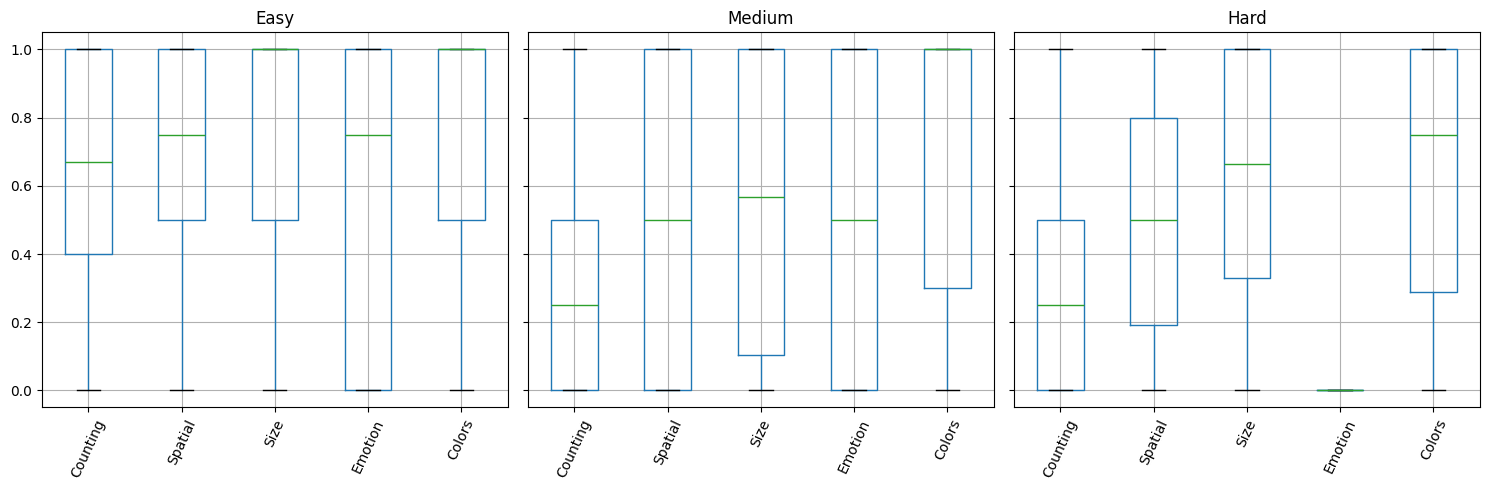

In [136]:
# Filter data for each level
easy = annotations_al[annotations_al["Level"] == "easy"]
medium = annotations_al[annotations_al["Level"] == "medium"]
hard = annotations_al[annotations_al["Level"] == "hard"]

# Create a figure with 3 subplots (one for each level)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Plot boxplots for each level
easy.boxplot(column=["Counting", "Spatial", "Size", "Emotion", "Colors"], ax=axes[0])
axes[0].set_title("Easy")

medium.boxplot(column=["Counting", "Spatial", "Size", "Emotion", "Colors"], ax=axes[1])
axes[1].set_title("Medium")

hard.boxplot(column=["Counting", "Spatial", "Size", "Emotion", "Colors"], ax=axes[2])
axes[2].set_title("Hard")

# Rotate x-axis labels for better readability
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=65)

plt.tight_layout()
plt.show()

In [137]:
annotations_al.groupby("Level")["Counting"].describe()

,count,mean,std,min,25%,50%,75%,max
Level,,,,,,,,
easy,82.0,0.629085,0.343020,0.0,0.4,0.67,1.0,1.0
hard,43.0,0.301279,0.289838,0.0,0.0,0.25,0.5,1.0
medium,47.0,0.353617,0.311409,0.0,0.0,0.25,0.5,1.0


## WER by level

In [138]:
annotations_al.groupby("Level")["WER"].describe()

,count,mean,std,min,25%,50%,75%,max
Level,,,,,,,,
easy,119.0,1.246499,1.024499,0.0,0.416667,1.0,2.0,3.0
hard,82.0,4.162372,3.268301,0.0,0.270833,6.0,7.0,9.0
medium,99.0,2.577189,2.336252,0.0,0.200000,2.0,5.0,6.0


## Spatial by level

In [139]:
annotations_al.groupby("Level")["Spatial"].describe()

,count,mean,std,min,25%,50%,75%,max
Level,,,,,,,,
easy,109.0,0.664740,0.35342,0.0,0.50000,0.75,1.0,1.0
hard,100.0,0.492089,0.36387,0.0,0.19125,0.50,0.8,1.0
medium,92.0,0.480163,0.39675,0.0,0.00000,0.50,1.0,1.0


## Size by level

In [140]:
annotations_al.groupby("Level")["Size"].describe()

,count,mean,std,min,25%,50%,75%,max
Level,,,,,,,,
easy,96.0,0.750625,0.395974,0.0,0.500,1.000000,1.0,1.0
hard,81.0,0.592695,0.382805,0.0,0.330,0.665000,1.0,1.0
medium,88.0,0.539867,0.382880,0.0,0.105,0.566667,1.0,1.0


## Emotion by level

In [141]:
annotations_al.groupby("Level")["Emotion"].describe()

,count,mean,std,min,25%,50%,75%,max
Level,,,,,,,,
easy,97.0,0.612079,0.429274,0.0,0.0,0.75,1.0,1.0
hard,3.0,0.000000,0.000000,0.0,0.0,0.00,0.0,0.0
medium,37.0,0.498919,0.451779,0.0,0.0,0.50,1.0,1.0


## Colors

In [142]:
annotations_al.groupby("Level")["Colors"].describe()

,count,mean,std,min,25%,50%,75%,max
Level,,,,,,,,
easy,125.0,0.769040,0.350444,0.0,0.5000,1.00,1.0,1.0
hard,100.0,0.628211,0.384378,0.0,0.2875,0.75,1.0,1.0
medium,94.0,0.668079,0.402274,0.0,0.3000,1.00,1.0,1.0


## Cohesiveness + easy : 78.5

In [143]:
annotations_al[annotations_al["Level"]=="easy"]["Cohesiveness"].value_counts()

Cohesiveness
True     65
True     30
False    26
Name: count, dtype: int64

## Cohesiveness + medium : 63

In [144]:
annotations_al[annotations_al["Level"]=="medium"]["Cohesiveness"].value_counts()

Cohesiveness
False    33
True     32
True     26
False     1
Name: count, dtype: int64

## Cohesiveness + hard : 114/202 = 56.43%

In [145]:
annotations_al[annotations_al["Level"]=="hard"]["Cohesiveness"].value_counts()

Cohesiveness
False    39
True     31
True     19
False     1
Name: count, dtype: int64

# Instances + Rules

In [247]:
lengths = []
rules_plus_instances = []

with open("../lengths.pkl", "rb") as file:
    lengths = pickle.load(file)

with open("../rules_plus_instances_2.pkl", "rb") as file:
    rules_plus_instances = pickle.load(file)

In [248]:
lengths

{'0_hard_001_0': 197,
 '0_hard_001_1': 175,
 '0_hard_001_2': 120,
 '0_hard_001_3': 169,
 '0_hard_001_4': 135,
 '0_medium_001_0': 162,
 '0_medium_001_1': 164,
 '0_medium_001_2': 133,
 '0_easy_001_0': 83,
 '0_easy_001_1': 70,
 '0_hard_001_0_robust': 174,
 '0_hard_001_1_robust': 170,
 '0_hard_001_2_robust': 173,
 '0_hard_001_3_robust': 175,
 '0_hard_001_4_robust': 173,
 '0_medium_001_0_robust': 107,
 '0_medium_001_1_robust': 109,
 '0_medium_001_2_robust': 111,
 '0_easy_001_0_robust': 56,
 '0_easy_001_1_robust': 55,
 '2_hard_001_0': 124,
 '2_hard_001_1': 113,
 '2_hard_001_2': 138,
 '2_hard_001_3': 101,
 '2_hard_001_4': 101,
 '2_medium_001_0': 124,
 '2_medium_001_1': 87,
 '2_medium_001_2': 71,
 '2_easy_001_0': 59,
 '2_easy_001_1': 77,
 '2_hard_001_0_robust': 97,
 '2_hard_001_1_robust': 97,
 '2_hard_001_2_robust': 96,
 '2_hard_001_3_robust': 97,
 '2_hard_001_4_robust': 94,
 '2_medium_001_0_robust': 77,
 '2_medium_001_1_robust': 77,
 '2_medium_001_2_robust': 78,
 '2_easy_001_0_robust': 52,
 '

In [249]:
def get_length(image_name:str):
    """_summary_

    Args:
        image_name (str): _description_
    """

    # Copy the image name
    image = image_name
    # Retrieve models name
    for model in MODELS:
        if model in image:
            # Remove the model name string
            image = image.replace(model+"_","")
            # Remove the extension
            image = image.replace(".png","")
            break

    if image in lengths:
        return lengths[image]
    
    return -1

In [250]:
def get_rules_plus_instances(image_name:str):
    """_summary_

    Args:
        image_name (str): _description_
    """

    # Copy the image name
    image = image_name
    # Retrieve models name
    for model in MODELS:
        if model in image:
            # Remove the model name string
            image = image.replace(model+"_","")
            # Remove the extension
            image = image.replace(".png","")
            break

    if image in rules_plus_instances:
        return rules_plus_instances[image]
    
    return -1

## Assigning

In [251]:
annotations["rules_plus_instances"] = annotations.Image.apply(lambda x: get_rules_plus_instances(x))
annotations["length"] = annotations.Image.apply(lambda x: get_length(x))
annotations.head()

,Image,Counting,WER,Spatial,Size,Emotion,Colors,Text,Cohesiveness,Code,Level,Robust,Skills,Typos,analyze_length,rules_plus_instances,length
0,stable_diffusion_0_easy_001_0.png,0.500,2.0,1.00,0.525,1.000,0.000,NaN,True,0,easy,False,6,False,False,14,83
1,stable_diffusion_0_easy_001_0_robust.png,0.585,2.0,1.00,0.500,0.500,0.415,NaN,True,0,easy,True,6,False,True,15,56
2,stable_diffusion_0_easy_001_1.png,0.500,2.0,0.00,0.000,0.000,0.000,NaN,False,0,easy,False,6,False,True,14,70
3,stable_diffusion_0_easy_001_1_robust.png,0.250,2.0,0.00,1.000,0.000,1.000,NaN,True,0,easy,True,6,False,True,15,55
4,stable_diffusion_0_hard_001_0.png,0.000,6.0,0.11,0.000,0.165,0.250,NaN,False,0,hard,False,6,False,False,118,197


In [252]:
annotations_b = annotations[["Counting","WER","Spatial","Size","Emotion","Colors","Cohesiveness","rules_plus_instances","length"]]
annotations_b["Cohesiveness"] = annotations_b.Cohesiveness.apply(lambda x: 1 if x not in [np.nan, ""] else 0)
annotations_b.head()

,Counting,WER,Spatial,Size,Emotion,Colors,Cohesiveness,rules_plus_instances,length
0,0.500,2.0,1.00,0.525,1.000,0.000,1,14,83
1,0.585,2.0,1.00,0.500,0.500,0.415,1,15,56
2,0.500,2.0,0.00,0.000,0.000,0.000,1,14,70
3,0.250,2.0,0.00,1.000,0.000,1.000,1,15,55
4,0.000,6.0,0.11,0.000,0.165,0.250,1,118,197


In [253]:
def compute_overall_accuracy(row):
    """_summary_
    """
    # Intialize the values
    values = 0
    # Check the number of not nan
    not_na = sum(pd.notna(row.values))-2
    # print values
    """print(f"Counting: {type(row['Counting'])}\n\
Spatial: {type(row['Spatial'])}\n\
Size: {type(row['Counting'])}\n\
Emotion: {type(row['Spatial'])}\n\
Colors: {type(row['Colors'])}\n\
Cohesiveness: {type(row['Cohesiveness'])}")"""
    # Counting 
    counting = np.nan if np.isnan(row["Counting"]) else row["Counting"]
    # Spatial 
    spatial = np.nan if np.isnan(row["Spatial"]) else row["Spatial"]
    # Size 
    size = np.nan if np.isnan(row["Size"]) else row["Size"]
    # Emotion 
    emotion = np.nan if np.isnan(row["Emotion"]) else row["Emotion"]
    # Colors 
    colors = np.nan if np.isnan(row["Colors"]) else row["Colors"]
    # Cohesiveness
    cohesiveness = np.nan if np.isnan(row["Cohesiveness"]) else row["Cohesiveness"]
    # Get the overall accuracy
    accuracy = [counting, spatial, size, emotion, colors, cohesiveness]

    for skill in accuracy:
        if not np.isnan(skill):
            values+=skill

    accuracy = values/not_na

    #print(f"Accuracy: {type(accuracy)}")

    return accuracy

In [254]:
overall_accuracies = []
for i,row in annotations_b.iterrows():
    # Get the overall accuracy
    overall_accuracy = compute_overall_accuracy(row)
    overall_accuracies.append(overall_accuracy)

In [255]:
#overall_accuracies

In [259]:
annotations_b["overall_accuracy"] = overall_accuracies

In [260]:
annotations_b["overall_accuracy"].describe()

count    1627.000000
mean        0.521646
std         0.262967
min         0.000000
25%         0.325500
50%         0.533333
75%         0.720000
max         1.000000
Name: overall_accuracy, dtype: float64

# Heatmaps

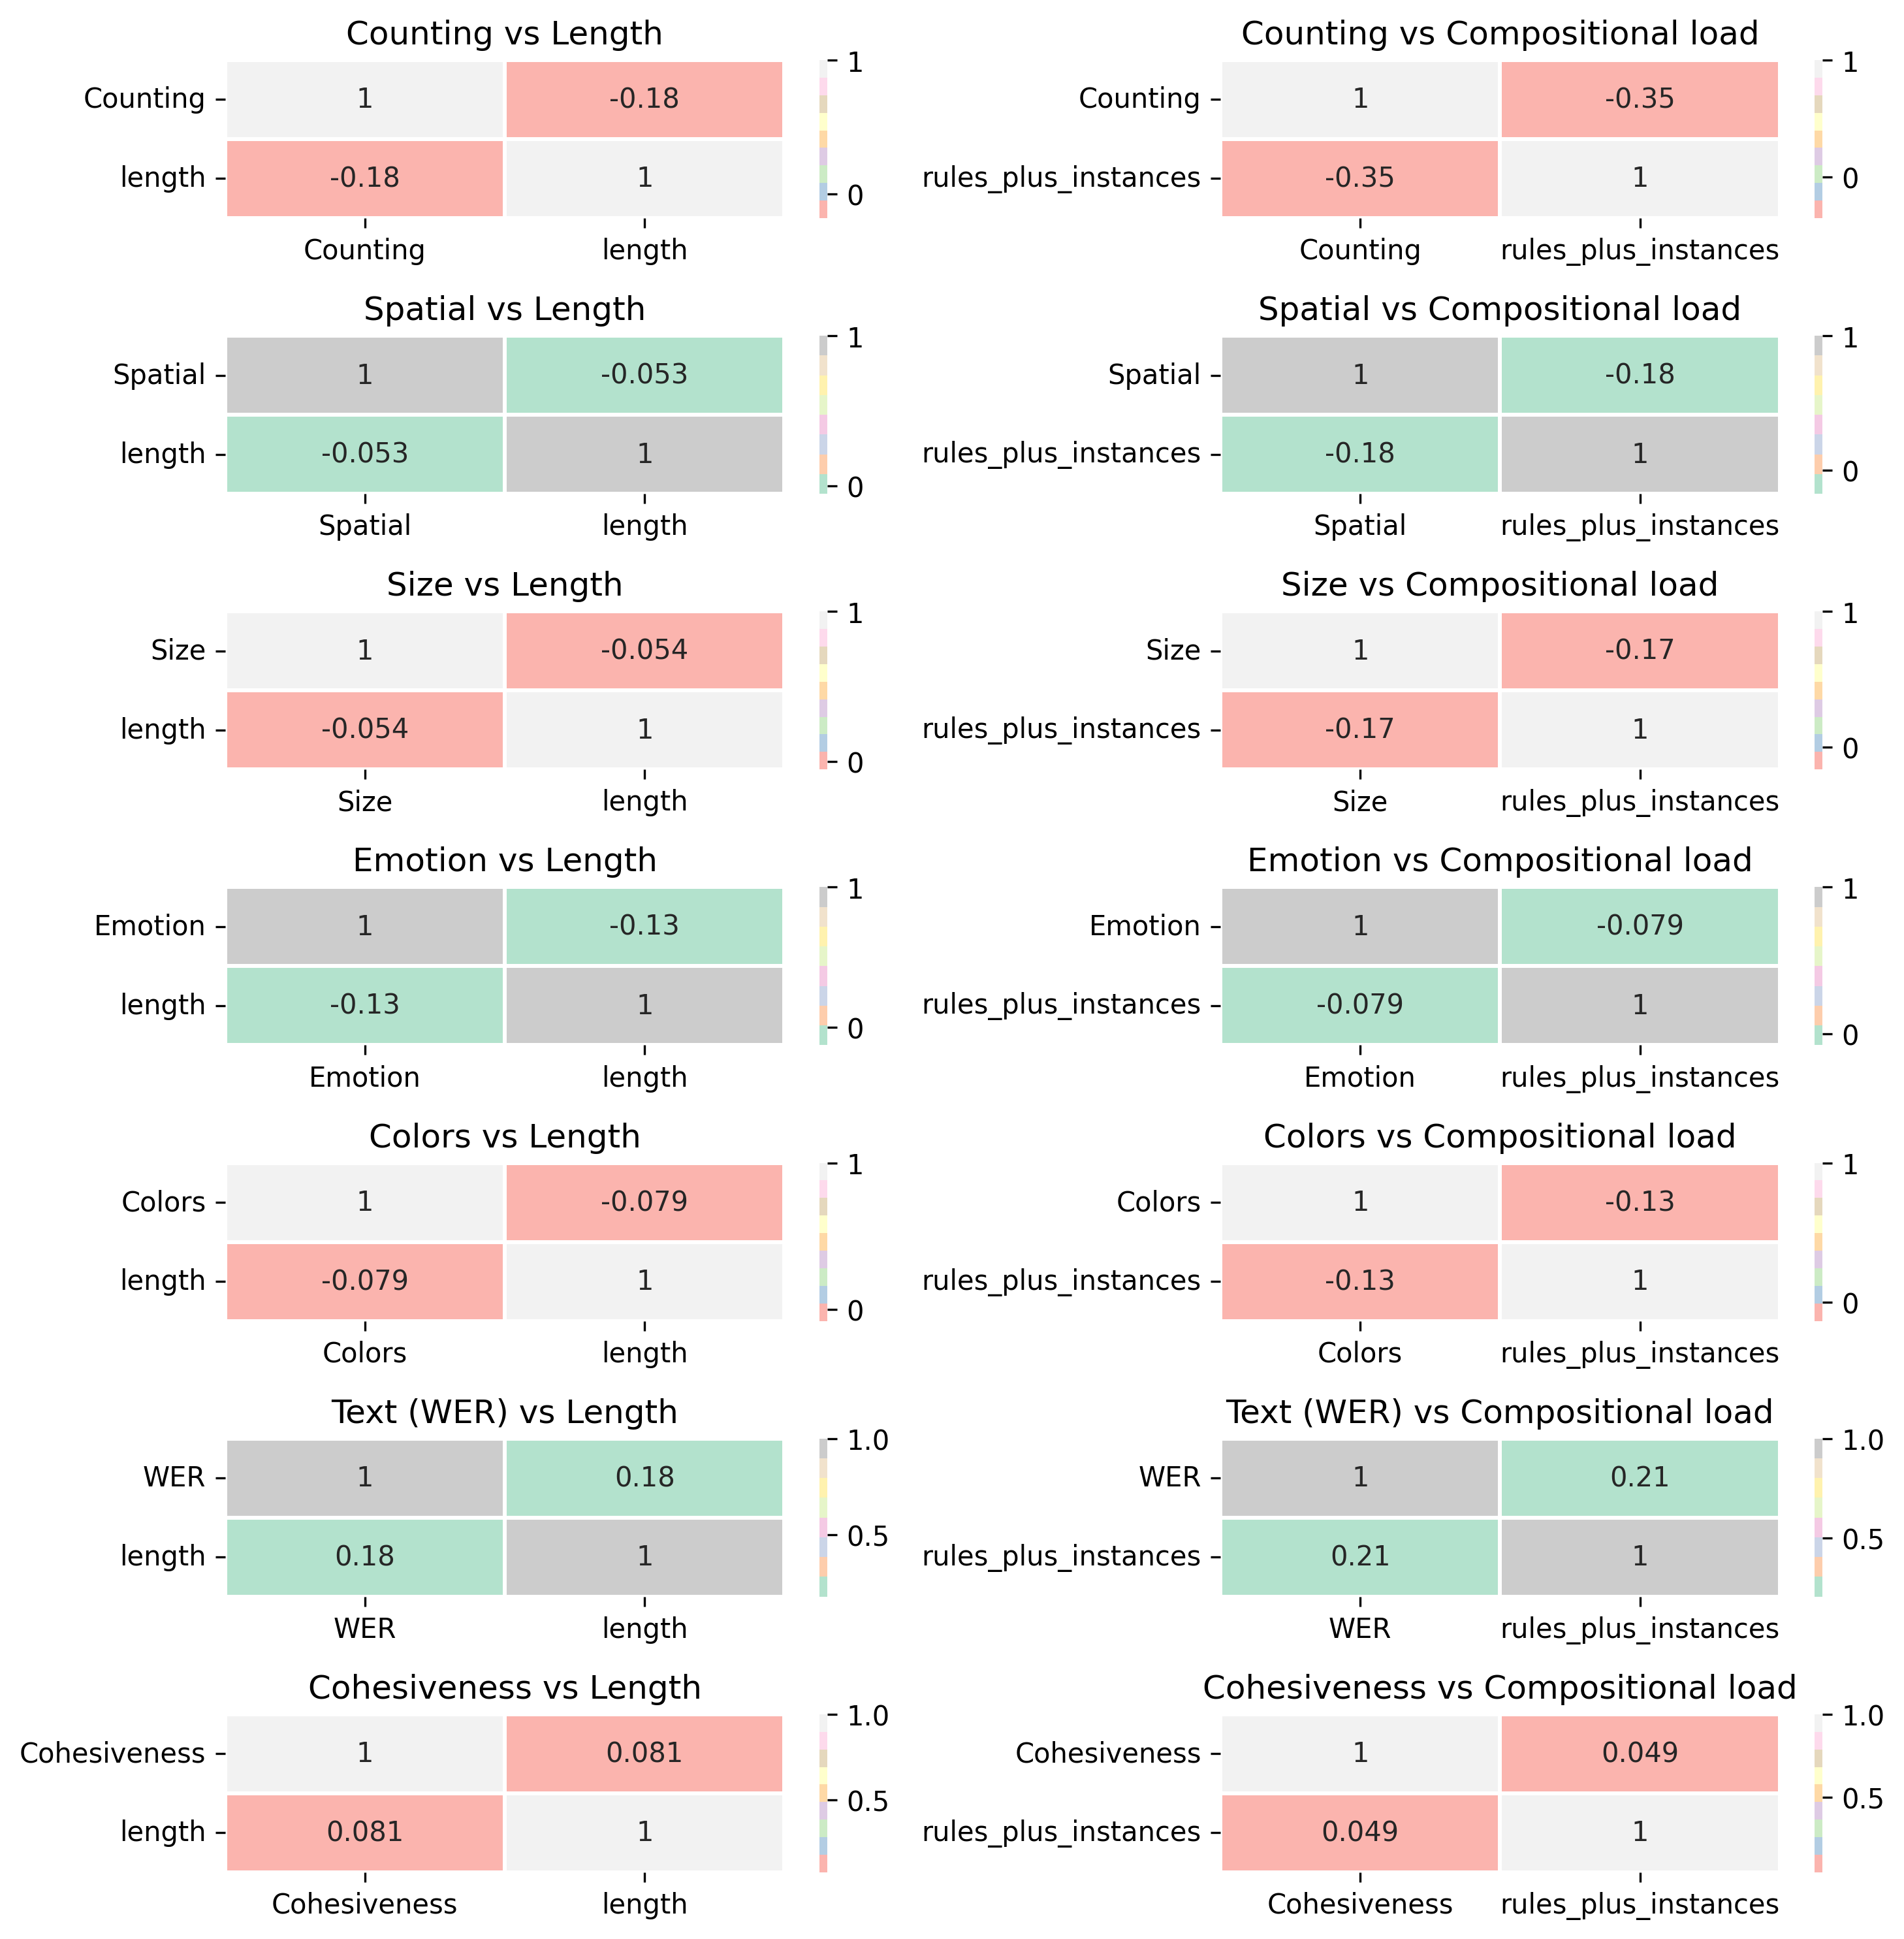

In [261]:
a_counting = annotations_b[["Counting", "length"]].corr()
b_counting = annotations_b[["Counting", "rules_plus_instances"]].corr()
a_spatial = annotations_b[["Spatial", "length"]].corr()
b_spatial = annotations_b[["Spatial", "rules_plus_instances"]].corr()
a_size = annotations_b[["Size", "length"]].corr()
b_size = annotations_b[["Size", "rules_plus_instances"]].corr()
a_emotion = annotations_b[["Emotion", "length"]].corr()
b_emotion = annotations_b[["Emotion", "rules_plus_instances"]].corr()
a_colors = annotations_b[["Colors", "length"]].corr()
b_colors = annotations_b[["Colors", "rules_plus_instances"]].corr()
a_text = annotations_b[["WER", "length"]].corr()
b_text = annotations_b[["WER", "rules_plus_instances"]].corr()
a_cohesiveness = annotations_b[["Cohesiveness", "length"]].corr()
b_cohesiveness = annotations_b[["Cohesiveness", "rules_plus_instances"]].corr()

# 7 rows, 2 columns
fig, axes = plt.subplots(7,2, figsize=(10, 10))  
fig.dpi = 300

# Counting
sns.heatmap(a_counting, annot=True, ax=axes[0][0], linewidths=1, cmap="Pastel1")
axes[0][0].set_title("Counting vs Length")
sns.heatmap(b_counting, annot=True, linewidths=1, ax=axes[0][1], cmap="Pastel1")
axes[0][1].set_title("Counting vs Compositional load")

# Spatial
sns.heatmap(a_spatial, annot=True, ax=axes[1][0], linewidths=1, cmap="Pastel2")
axes[1][0].set_title("Spatial vs Length")
sns.heatmap(b_spatial, annot=True, ax=axes[1][1], linewidths=1, cmap="Pastel2")
axes[1][1].set_title("Spatial vs Compositional load")

# Size
sns.heatmap(a_size, annot=True, ax=axes[2][0], linewidths=1, cmap="Pastel1")
axes[2][0].set_title("Size vs Length")
sns.heatmap(b_size, annot=True, ax=axes[2][1], linewidths=1, cmap="Pastel1")
axes[2][1].set_title("Size vs Compositional load")

# Emotion
sns.heatmap(a_emotion, annot=True, ax=axes[3][0], linewidths=1, cmap="Pastel2")
axes[3][0].set_title("Emotion vs Length")
sns.heatmap(b_emotion, annot=True, ax=axes[3][1], linewidths=1, cmap="Pastel2")
axes[3][1].set_title("Emotion vs Compositional load")

# Colors
sns.heatmap(a_colors, annot=True, ax=axes[4][0], linewidths=1, cmap="Pastel1")
axes[4][0].set_title("Colors vs Length")
sns.heatmap(b_colors, annot=True, ax=axes[4][1], linewidths=1, cmap="Pastel1")
axes[4][1].set_title("Colors vs Compositional load")

# WERx&
sns.heatmap(a_text, annot=True, ax=axes[5][0], linewidths=1, cmap="Pastel2")
axes[5][0].set_title("Text (WER) vs Length")
sns.heatmap(b_text, annot=True, ax=axes[5][1], linewidths=1, cmap="Pastel2")
axes[5][1].set_title("Text (WER) vs Compositional load")

# Cohesiveness
sns.heatmap(a_cohesiveness, annot=True, ax=axes[6][0], linewidths=1, cmap="Pastel1")
axes[6][0].set_title("Cohesiveness vs Length")
sns.heatmap(b_cohesiveness, annot=True, ax=axes[6][1], linewidths=1, cmap="Pastel1")
axes[6][1].set_title("Cohesiveness vs Compositional load")

# Force no rotation
for ax_row in axes:
    for ax in ax_row:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)


plt.tight_layout()
plt.savefig("../complete_heatmap.png", transparent=True)
plt.show()

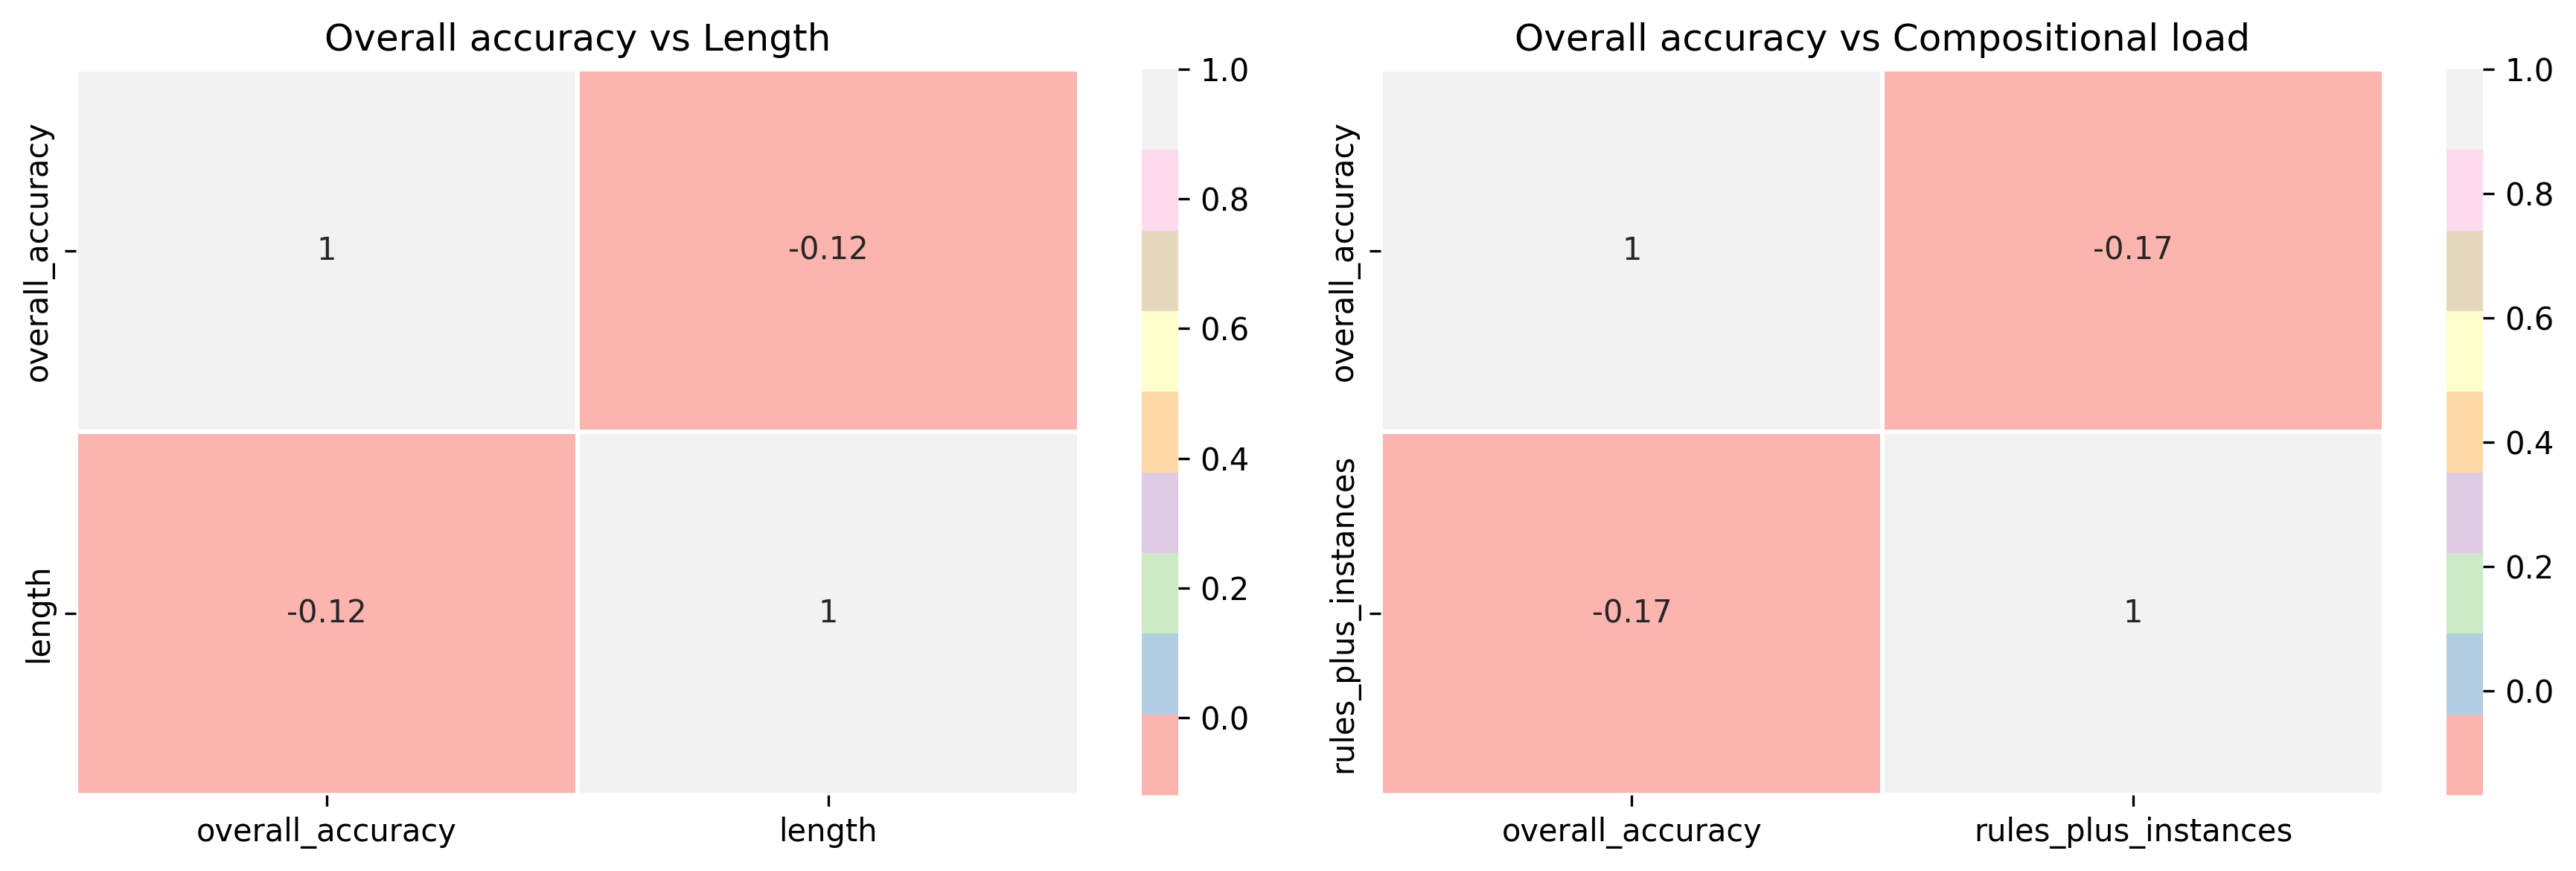

In [300]:
a_accuracy= annotations_b[["overall_accuracy", "length"]].corr()
b_accuracy = annotations_b[["overall_accuracy", "rules_plus_instances"]].corr()

# 1 rows, 2 columns
fig, axes = plt.subplots(1,2, figsize=(12, 4))  
fig.dpi = 300

sns.heatmap(a_accuracy, annot=True, ax=axes[0], linewidths=1, cmap="Pastel1")
axes[0].set_title("Overall accuracy vs Length")
sns.heatmap(b_accuracy, annot=True, linewidths=1, ax=axes[1], cmap="Pastel1")
axes[1].set_title("Overall accuracy vs Compositional load")

# Force no rotation
for ax_row in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("../non_complete_heatmap.png", transparent=True)
plt.show()

# Regression lines

## Counting

In [263]:
# Length
# Setting the axis 
annotations_b_counting = annotations_b.dropna(subset=["Counting"])
X_counting = annotations_b_counting[["length"]].values.tolist()
Y_counting = annotations_b_counting[["Counting"]].values.tolist()

model = LinearRegression().fit(X_counting,Y_counting)
print(model.coef_)
print(model.intercept_)

# Rules + instances
# Setting the axis 
annotations_b_counting = annotations_b.dropna(subset=["Counting"])
X_counting = annotations_b_counting[["rules_plus_instances"]].values.tolist()
Y_counting = annotations_b_counting[["Counting"]].values.tolist()

model = LinearRegression().fit(X_counting,Y_counting)
print(model.coef_)
print(model.intercept_)

[[-0.00133844]]
[0.51461145]
[[-0.00329401]]
[0.51191027]


In [264]:
# Length
# Setting the axis 
scaler = StandardScaler()
annotations_b_counting = annotations_b.dropna(subset=["Counting"])
X_counting = annotations_b_counting[["length", "rules_plus_instances"]]
X_counting = scaler.fit_transform(X_counting)
Y_counting = annotations_b_counting[["Counting"]]
Y_counting = (Y_counting - Y_counting.mean()) / Y_counting.std()
# Adding the intercept
X_counting = sm.add_constant(X_counting)
# Fitting the model 
model = sm.OLS(Y_counting,X_counting).fit()
# Full summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:               Counting   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     49.20
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           1.04e-20
Time:                        17:08:11   Log-Likelihood:                -943.71
No. Observations:                 698   AIC:                             1893.
Df Residuals:                     695   BIC:                             1907.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -1.11e-16      0.035  -3.13e-15      1.0

In [265]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = annotations_b_counting[["length", "rules_plus_instances"]]
print(len(X_vif))
X_vif = (
    annotations_b_counting[["length", "rules_plus_instances"]]
    .dropna()
)
print(len(X_vif))


vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_df)
print("N =", len(annotations_b_counting))

698
698
               Variable       VIF
0                length  3.524588
1  rules_plus_instances  3.524588
N = 698


In [266]:
X_vif.isna().sum()

length                  0
rules_plus_instances    0
dtype: int64

In [267]:
# Coefficients
print(f"Params: \n{model.params}\n-------------------------------------------------------------")

# P-values
print(f"P-values: {model.pvalues}\n-------------------------------------------------------------")

# Confidence intervals
print(f"Confidence intervals: \n{model.conf_int()}\n-------------------------------------------------------------")

# Standard errors
print(f"Standard errors: \n{model.bse}\n-------------------------------------------------------------")

Params: 
const   -1.110223e-16
x1       2.160618e-02
x2      -3.634346e-01
dtype: float64
-------------------------------------------------------------
P-values: const    1.000000e+00
x1       6.124445e-01
x2       9.485905e-17
dtype: float64
-------------------------------------------------------------
Confidence intervals: 
              0         1
const -0.069654  0.069654
x1    -0.062095  0.105308
x2    -0.447136 -0.279733
-------------------------------------------------------------
Standard errors: 
const    0.035477
x1       0.042631
x2       0.042631
dtype: float64
-------------------------------------------------------------


## Spatial

In [268]:
# Length
# Setting the axis 
annotations_b_spatial = annotations_b.dropna(subset=["Spatial"])
X_spatial = annotations_b_spatial[["length"]].values.tolist()
Y_spatial = annotations_b_spatial[["Spatial"]].values.tolist()

model = LinearRegression().fit(X_spatial,Y_spatial)
print(model.coef_)
print(model.intercept_)

# Rules + instances
# Setting the axis 
annotations_b_spatial = annotations_b.dropna(subset=["Spatial"])
X_spatial = annotations_b_spatial[["rules_plus_instances"]].values.tolist()
Y_spatial = annotations_b_spatial[["Spatial"]].values.tolist()

model = LinearRegression().fit(X_spatial,Y_spatial)
print(model.coef_)
print(model.intercept_)

[[-0.00048831]]
[0.56980322]
[[-0.0024322]]
[0.59553602]


In [269]:
X_vif = annotations_b_spatial[["length", "rules_plus_instances"]].dropna()

vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_df)
print("N =", len(annotations_b_spatial))

               Variable       VIF
0                length  2.833955
1  rules_plus_instances  2.833955
N = 1164


In [270]:
# Length
# Setting the axis 
scaler = StandardScaler()
annotations_b_spatial = annotations_b.dropna(subset=["Spatial"])
X_spatial = annotations_b_spatial[["length", "rules_plus_instances"]]
X_spatial = scaler.fit_transform(X_spatial)
Y_spatial = annotations_b_spatial[["Spatial"]]
Y_spatial = (Y_spatial- Y_spatial.mean()) / Y_spatial.std()
# Adding the intercept
X_spatial = sm.add_constant(X_spatial)
# Fitting the model 
model = sm.OLS(Y_spatial,X_spatial).fit()
# Full summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Spatial   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     19.04
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           7.31e-09
Time:                        17:08:23   Log-Likelihood:                -1632.4
No. Observations:                1164   AIC:                             3271.
Df Residuals:                    1161   BIC:                             3286.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.302e-16      0.029   1.49e-14      1.0

In [271]:
# Coefficients
print(f"Params: \n{model.params}\n-------------------------------------------------------------")

# P-values
print(f"P-values: {model.pvalues}\n-------------------------------------------------------------")

# Confidence intervals
print(f"Confidence intervals: \n{model.conf_int()}\n-------------------------------------------------------------")

# Standard errors
print(f"Standard errors: \n{model.bse}\n-------------------------------------------------------------")

Params: 
const    4.302114e-16
x1       3.407303e-02
x2      -1.909869e-01
dtype: float64
-------------------------------------------------------------
P-values: const    1.000000e+00
x1       2.931243e-01
x2       4.894360e-09
dtype: float64
-------------------------------------------------------------
Confidence intervals: 
              0         1
const -0.056636  0.056636
x1    -0.029488  0.097634
x2    -0.254548 -0.127426
-------------------------------------------------------------
Standard errors: 
const    0.028866
x1       0.032396
x2       0.032396
dtype: float64
-------------------------------------------------------------


## Size 

In [272]:
# Length
# Setting the axis 
annotations_b_size = annotations_b.dropna(subset=["Size"])
X_size = annotations_b_size[["length"]].values.tolist()
Y_size = annotations_b_size[["Size"]].values.tolist()

model = LinearRegression().fit(X_size,Y_size)
print(model.coef_)
print(model.intercept_)

# Rules + instances
# Setting the axis 
annotations_b_size = annotations_b.dropna(subset=["Size"])
X_size = annotations_b_size[["rules_plus_instances"]].values.tolist()
Y_size = annotations_b_size[["Size"]].values.tolist()

model = LinearRegression().fit(X_size,Y_size)
print(model.coef_)
print(model.intercept_)

[[-0.00052852]]
[0.63507056]
[[-0.00240246]]
[0.66283275]


In [273]:
# Length
# Setting the axis 
annotations_b_size = annotations_b.dropna(subset=["Size"])
X_size = annotations_b_size[["length","rules_plus_instances"]].values.tolist()
Y_size = annotations_b_size[["Size"]].values.tolist()

model = LinearRegression().fit(X_size,Y_size)
print(model.coef_)
print(model.intercept_)

[[ 0.00040991 -0.00270711]]
[0.6330124]


In [274]:
X_vif = annotations_b_size[["length", "rules_plus_instances"]]

vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_df)
print("N =", len(annotations_b_size))

               Variable       VIF
0                length  3.150924
1  rules_plus_instances  3.150924
N = 1008


In [275]:
# Length
# Setting the axis 
scaler = StandardScaler()
annotations_b_size = annotations_b.dropna(subset=["Size"])
X_size = annotations_b_size[["length", "rules_plus_instances"]]
X_size = scaler.fit_transform(X_size)
Y_size = annotations_b_size[["Size"]]
Y_size = (Y_size- Y_size.mean()) / Y_size.std()
# Adding the intercept
X_size = sm.add_constant(X_size)
# Fitting the model 
model = sm.OLS(Y_size,X_size).fit()
# Full summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Size   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     15.14
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           3.31e-07
Time:                        17:08:34   Log-Likelihood:                -1414.8
No. Observations:                1008   AIC:                             2836.
Df Residuals:                    1005   BIC:                             2850.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        2.22e-16      0.031   7.15e-15      1.0

In [276]:
# Coefficients
print(f"Params: \n{model.params}\n-------------------------------------------------------------")

# P-values
print(f"P-values: {model.pvalues}\n-------------------------------------------------------------")

# Confidence intervals
print(f"Confidence intervals: \n{model.conf_int()}\n-------------------------------------------------------------")

# Standard errors
print(f"Standard errors: \n{model.bse}\n-------------------------------------------------------------")

Params: 
const    2.220446e-16
x1       4.175487e-02
x2      -1.883285e-01
dtype: float64
-------------------------------------------------------------
P-values: const    1.000000e+00
x1       2.470810e-01
x2       2.132720e-07
dtype: float64
-------------------------------------------------------------
Confidence intervals: 
              0         1
const -0.060957  0.060957
x1    -0.028994  0.112503
x2    -0.259077 -0.117580
-------------------------------------------------------------
Standard errors: 
const    0.031064
x1       0.036053
x2       0.036053
dtype: float64
-------------------------------------------------------------


## Emotion

In [277]:
# Length
# Setting the axis 
annotations_b_emotion = annotations_b.dropna(subset=["Emotion"])
X_emotion = annotations_b_emotion[["length"]].values.tolist()
Y_emotion = annotations_b_emotion[["Emotion"]].values.tolist()

model = LinearRegression().fit(X_emotion,Y_emotion)
print(model.coef_)
print(model.intercept_)

# Rules + instances
# Setting the axis 
annotations_b_size = annotations_b.dropna(subset=["Size"])
X_emotion = annotations_b_emotion[["rules_plus_instances"]].values.tolist()
Y_emotion = annotations_b_emotion[["Emotion"]].values.tolist()

model = LinearRegression().fit(X_emotion,Y_emotion)
print(model.coef_)
print(model.intercept_)

[[-0.00152056]]
[0.63912144]
[[-0.00114496]]
[0.49957049]


In [278]:
# Length
# Setting the axis 
annotations_b_emotion = annotations_b.dropna(subset=["Emotion"])
X_emotion = annotations_b_emotion[["length","rules_plus_instances"]].values.tolist()
Y_emotion = annotations_b_emotion[["Emotion"]].values.tolist()

model = LinearRegression().fit(X_emotion,Y_emotion)
print(model.coef_)
print(model.intercept_)

[[-0.00143517 -0.00018862]]
[0.63531623]


In [279]:
X_vif = annotations_b_emotion[["length", "rules_plus_instances"]]

vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_df)
print("N =", len(annotations_b_emotion))

               Variable       VIF
0                length  3.037046
1  rules_plus_instances  3.037046
N = 967


In [280]:
# Length
# Setting the axis 
scaler = StandardScaler()
annotations_b_emotion = annotations_b.dropna(subset=["Emotion"])
X_emotion = annotations_b_emotion[["length", "rules_plus_instances"]]
X_emotion = scaler.fit_transform(X_emotion)
Y_emotion = annotations_b_emotion[["Emotion"]]
Y_emotion = (Y_emotion - Y_emotion.mean()) / Y_emotion.std()
# Adding the intercept
X_emotion = sm.add_constant(X_emotion)
# Fitting the model 
model = sm.OLS(Y_emotion,X_emotion).fit()
# Full summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Emotion   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     8.028
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           0.000349
Time:                        17:08:42   Log-Likelihood:                -1363.6
No. Observations:                 967   AIC:                             2733.
Df Residuals:                     964   BIC:                             2748.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.914e-16      0.032  -9.13e-15      1.0

In [281]:
# Coefficients
print(f"Params: \n{model.params}\n-------------------------------------------------------------")

# P-values
print(f"P-values: {model.pvalues}\n-------------------------------------------------------------")

# Confidence intervals
print(f"Confidence intervals: \n{model.conf_int()}\n-------------------------------------------------------------")

# Standard errors
print(f"Standard errors: \n{model.bse}\n-------------------------------------------------------------")

Params: 
const   -2.914335e-16
x1      -1.203041e-01
x2      -1.303234e-02
dtype: float64
-------------------------------------------------------------
P-values: const    1.000000
x1       0.001689
x2       0.733090
dtype: float64
-------------------------------------------------------------
Confidence intervals: 
              0         1
const -0.062653  0.062653
x1    -0.195279 -0.045330
x2    -0.088007  0.061942
-------------------------------------------------------------
Standard errors: 
const    0.031926
x1       0.038205
x2       0.038205
dtype: float64
-------------------------------------------------------------


## Colors

In [282]:
# Length
# Setting the axis 
annotations_b_colors = annotations_b.dropna(subset=["Colors"])
X_colors = annotations_b_colors[["length"]].values.tolist()
Y_colors = annotations_b_colors[["Colors"]].values.tolist()

model = LinearRegression().fit(X_colors,Y_colors)
print(model.coef_)
print(model.intercept_)

# Rules + instances
# Setting the axis 
annotations_b_colors = annotations_b.dropna(subset=["Colors"])
X_colors = annotations_b_colors[["rules_plus_instances"]].values.tolist()
Y_colors = annotations_b_colors[["Colors"]].values.tolist()

model = LinearRegression().fit(X_colors,Y_colors)
print(model.coef_)
print(model.intercept_)

[[-0.00074957]]
[0.73081823]
[[-0.00185348]]
[0.72225065]


In [283]:
X_vif = annotations_b_colors[["length", "rules_plus_instances"]]

vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_df)
print("N =", len(annotations_b_colors))

               Variable      VIF
0                length  3.50065
1  rules_plus_instances  3.50065
N = 1202


In [284]:
# Length
# Setting the axis 
annotations_b_colors = annotations_b.dropna(subset=["Colors"])
X_colors = annotations_b_colors[["length","rules_plus_instances"]].values.tolist()
Y_colors = annotations_b_colors[["Colors"]].values.tolist()

model = LinearRegression().fit(X_colors,Y_colors)
print(model.coef_)
print(model.intercept_)

[[-7.07727482e-05 -1.79691984e-03]]
[0.72705433]


In [285]:
# Length
# Setting the axis 
scaler = StandardScaler()
annotations_b_colors = annotations_b.dropna(subset=["Colors"])
X_colors = annotations_b_colors[["length", "rules_plus_instances"]]
X_colors = scaler.fit_transform(X_colors)
Y_colors = annotations_b_colors["Colors"]
Y_colors = (Y_colors - Y_colors.mean()) / Y_colors.std()
# Adding the intercept
X_colors = sm.add_constant(X_colors)
# Fitting the model 
model = sm.OLS(Y_colors,X_colors).fit()
# Full summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Colors   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     10.94
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           1.95e-05
Time:                        17:08:48   Log-Likelihood:                -1694.2
No. Observations:                1202   AIC:                             3394.
Df Residuals:                    1199   BIC:                             3410.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7.702e-16      0.029  -2.69e-14      1.0

In [286]:
# Coefficients
print(f"Params: \n{model.params}\n-------------------------------------------------------------")

# P-values
print(f"P-values: {model.pvalues}\n-------------------------------------------------------------")

# Confidence intervals
print(f"Confidence intervals: \n{model.conf_int()}\n-------------------------------------------------------------")

# Standard errors
print(f"Standard errors: \n{model.bse}\n-------------------------------------------------------------")

Params: 
const   -7.702172e-16
x1      -7.424745e-03
x2      -1.296027e-01
dtype: float64
-------------------------------------------------------------
P-values: const    1.000000
x1       0.828364
x2       0.000161
dtype: float64
-------------------------------------------------------------
Confidence intervals: 
              0         1
const -0.056127  0.056127
x1    -0.074601  0.059751
x2    -0.196779 -0.062427
-------------------------------------------------------------
Standard errors: 
const    0.028608
x1       0.034240
x2       0.034240
dtype: float64
-------------------------------------------------------------


## Text (WER)

In [287]:
# Length
# Setting the axis 
annotations_b_text = annotations_b.dropna(subset=["WER"])
X_text = annotations_b_text[["length"]].values.tolist()
Y_text = annotations_b_text[["WER"]].values.tolist()

model = LinearRegression().fit(X_text,Y_text)
print(model.coef_)
print(model.intercept_)

# Rules + instances
# Setting the axis 
annotations_b_colors = annotations_b.dropna(subset=["WER"])
X_text = annotations_b_text[["rules_plus_instances"]].values.tolist()
Y_text = annotations_b_text[["WER"]].values.tolist()

model = LinearRegression().fit(X_text,Y_text)
print(model.coef_)
print(model.intercept_)

[[0.01358779]]
[1.65937828]
[[0.02089449]]
[2.38471103]


In [288]:
# Length
# Setting the axis 
annotations_b_text = annotations_b.dropna(subset=["WER"])
X_text = annotations_b_text[["length","rules_plus_instances"]].values.tolist()
Y_text = annotations_b_text[["WER"]].values.tolist()

model = LinearRegression().fit(X_text,Y_text)
print(model.coef_)
print(model.intercept_)

[[0.00699572 0.01576581]]
[1.83681641]


In [289]:
X_vif = annotations_b_text[["length", "rules_plus_instances"]]

vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_df)
print("N =", len(annotations_b_text))

               Variable       VIF
0                length  3.071083
1  rules_plus_instances  3.071083
N = 934


In [290]:
# Length
# Setting the axis 
scaler = StandardScaler()
annotations_b_wer = annotations_b.dropna(subset=["WER"])
X_wer= annotations_b_wer[["length", "rules_plus_instances"]]
X_wer = scaler.fit_transform(X_wer)
Y_wer = annotations_b_wer["WER"]
Y_wer = (Y_wer - Y_wer.mean()) / Y_wer.std()
# Adding the intercept
X_wer = sm.add_constant(X_wer)
# Fitting the model 
model = sm.OLS(Y_wer,X_wer).fit()
# Full summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    WER   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     23.41
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           1.20e-10
Time:                        17:08:56   Log-Likelihood:                -1301.9
No. Observations:                 934   AIC:                             2610.
Df Residuals:                     931   BIC:                             2624.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.378e-17      0.032   1.68e-15      1.0

In [291]:
# Coefficients
print(f"Params: \n{model.params}\n-------------------------------------------------------------")

# P-values
print(f"P-values: {model.pvalues}\n-------------------------------------------------------------")

# Confidence intervals
print(f"Confidence intervals: \n{model.conf_int()}\n-------------------------------------------------------------")

# Standard errors
print(f"Standard errors: \n{model.bse}\n-------------------------------------------------------------")

Params: 
const    5.377643e-17
x1       9.096441e-02
x2       1.548180e-01
dtype: float64
-------------------------------------------------------------
P-values: const    1.000000
x1       0.017991
x2       0.000059
dtype: float64
-------------------------------------------------------------
Confidence intervals: 
              0         1
const -0.062726  0.062726
x1     0.015640  0.166289
x2     0.079493  0.230143
-------------------------------------------------------------
Standard errors: 
const    0.031962
x1       0.038382
x2       0.038382
dtype: float64
-------------------------------------------------------------


## Cohesiveness

In [292]:
sum(pd.notna(annotations_b.Cohesiveness))

1627

In [293]:
# Length
# Setting the axis 
annotations_b_cohesiveness = annotations_b.dropna(subset=["Cohesiveness"])
X_cohesiveness = annotations_b_cohesiveness[["length"]].values.tolist()
Y_cohesiveness = annotations_b_cohesiveness[["Cohesiveness"]].values.tolist()

model = LinearRegression().fit(X_cohesiveness,Y_cohesiveness)
print(model.coef_)
print(model.intercept_)

# Rules + instances
# Setting the axis 
annotations_b_cohesiveness = annotations_b.dropna(subset=["Cohesiveness"])
X_cohesiveness = annotations_b_cohesiveness[["rules_plus_instances"]].values.tolist()
Y_cohesiveness = annotations_b_cohesiveness[["Cohesiveness"]].values.tolist()

model = LinearRegression().fit(X_cohesiveness,Y_cohesiveness)
print(model.coef_)
print(model.intercept_)

[[0.00089024]]
[0.64575724]
[[0.00085083]]
[0.70659997]


In [294]:
# Length
# Setting the axis 
annotations_b_cohesiveness = annotations_b.dropna(subset=["Cohesiveness"])
X_cohesiveness = annotations_b_cohesiveness[["length","rules_plus_instances"]].values.tolist()
Y_cohesiveness = annotations_b_cohesiveness[["Cohesiveness"]].values.tolist()

model = LinearRegression().fit(X_cohesiveness,Y_cohesiveness)
print(model.coef_)
print(model.intercept_)

[[0.00080986 0.0002743 ]]
[0.6454927]


In [295]:
X_vif = annotations_b_cohesiveness[["length", "rules_plus_instances"]]

vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_df)
print("N =", len(annotations_b_cohesiveness))

               Variable       VIF
0                length  2.887111
1  rules_plus_instances  2.887111
N = 1627


In [296]:
# Length
# Setting the axis 
scaler = StandardScaler()
annotations_b_cohesiveness = annotations_b.dropna(subset=["Cohesiveness"])
X_cohesiveness = annotations_b_cohesiveness[["length", "rules_plus_instances"]]
X_cohesiveness = scaler.fit_transform(X_cohesiveness)
Y_cohesiveness = annotations_b_cohesiveness["Cohesiveness"]
Y_cohesiveness = (Y_cohesiveness - Y_cohesiveness.mean()) / Y_cohesiveness.std()
# Adding the intercept
X_cohesiveness = sm.add_constant(X_cohesiveness)
# Fitting the model 
model = sm.OLS(Y_cohesiveness,X_cohesiveness).fit()
# Full summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Cohesiveness   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     5.462
Date:                Mon, 03 Aug 2026   Prob (F-statistic):            0.00432
Time:                        17:09:01   Log-Likelihood:                -2302.7
No. Observations:                1627   AIC:                             4611.
Df Residuals:                    1624   BIC:                             4628.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -2.29e-16      0.025  -9.26e-15      1.0

In [297]:
# Coefficients
print(f"Params: \n{model.params}\n-------------------------------------------------------------")

# P-values
print(f"P-values: {model.pvalues}\n-------------------------------------------------------------")

# Confidence intervals
print(f"Confidence intervals: \n{model.conf_int()}\n-------------------------------------------------------------")

# Standard errors
print(f"Standard errors: \n{model.bse}\n-------------------------------------------------------------")

Params: 
const   -2.289835e-16
x1       7.321700e-02
x2       1.591049e-02
dtype: float64
-------------------------------------------------------------
P-values: const    1.000000
x1       0.008507
x2       0.567074
dtype: float64
-------------------------------------------------------------
Confidence intervals: 
              0         1
const -0.048494  0.048494
x1     0.018705  0.127729
x2    -0.038602  0.070423
-------------------------------------------------------------
Standard errors: 
const    0.024724
x1       0.027792
x2       0.027792
dtype: float64
-------------------------------------------------------------


In [298]:
rules_plus_instances

{'0_hard_001_0': 118,
 '0_hard_001_1': 118,
 '0_hard_001_2': 118,
 '0_hard_001_3': 118,
 '0_hard_001_4': 118,
 '0_medium_001_0': 39,
 '0_medium_001_1': 39,
 '0_medium_001_2': 39,
 '0_easy_001_0': 14,
 '0_easy_001_1': 14,
 '0_hard_001_0_robust': 113,
 '0_hard_001_1_robust': 113,
 '0_hard_001_2_robust': 113,
 '0_hard_001_3_robust': 113,
 '0_hard_001_4_robust': 113,
 '0_medium_001_0_robust': 52,
 '0_medium_001_1_robust': 52,
 '0_medium_001_2_robust': 52,
 '0_easy_001_0_robust': 15,
 '0_easy_001_1_robust': 15,
 '2_hard_001_0': 23,
 '2_hard_001_1': 23,
 '2_hard_001_2': 23,
 '2_hard_001_3': 23,
 '2_hard_001_4': 23,
 '2_medium_001_0': 13,
 '2_medium_001_1': 13,
 '2_medium_001_2': 13,
 '2_easy_001_0': 7,
 '2_easy_001_1': 7,
 '2_hard_001_0_robust': 24,
 '2_hard_001_1_robust': 24,
 '2_hard_001_2_robust': 24,
 '2_hard_001_3_robust': 24,
 '2_hard_001_4_robust': 24,
 '2_medium_001_0_robust': 14,
 '2_medium_001_1_robust': 14,
 '2_medium_001_2_robust': 14,
 '2_easy_001_0_robust': 8,
 '2_easy_001_1_ro